<a href="https://colab.research.google.com/github/ncode-collab/Oral_Cancer_Risk_Analysis/blob/main/Oral_Cancer_Risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [15]:
data = pd.read_csv('oral_cancer_prediction_dataset.csv')

In [16]:
data.shape

(84922, 25)

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84922 entries, 0 to 84921
Data columns (total 25 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   ID                                        84922 non-null  int64  
 1   Country                                   84922 non-null  object 
 2   Age                                       84922 non-null  int64  
 3   Gender                                    84922 non-null  object 
 4   Tobacco Use                               84922 non-null  object 
 5   Alcohol Consumption                       84922 non-null  object 
 6   HPV Infection                             84922 non-null  object 
 7   Betel Quid Use                            84922 non-null  object 
 8   Chronic Sun Exposure                      84922 non-null  object 
 9   Poor Oral Hygiene                         84922 non-null  object 
 10  Diet (Fruits & Vegetables Intake) 

In [18]:
for col in data.columns:
    print(col)

ID
Country
Age
Gender
Tobacco Use
Alcohol Consumption
HPV Infection
Betel Quid Use
Chronic Sun Exposure
Poor Oral Hygiene
Diet (Fruits & Vegetables Intake)
Family History of Cancer
Compromised Immune System
Oral Lesions
Unexplained Bleeding
Difficulty Swallowing
White or Red Patches in Mouth
Tumor Size (cm)
Cancer Stage
Treatment Type
Survival Rate (5-Year, %)
Cost of Treatment (USD)
Economic Burden (Lost Workdays per Year)
Early Diagnosis
Oral Cancer (Diagnosis)


In [19]:
data.head()

,ID,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,...,Difficulty Swallowing,White or Red Patches in Mouth,Tumor Size (cm),Cancer Stage,Treatment Type,"Survival Rate (5-Year, %)",Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis)
0,1,Italy,36,Female,Yes,Yes,Yes,No,No,Yes,...,No,No,0.000000,0,No Treatment,100.000000,0.00,0,No,No
1,2,Japan,64,Male,Yes,Yes,Yes,No,Yes,Yes,...,No,No,1.782186,1,No Treatment,83.340103,77772.50,177,No,Yes
2,3,UK,37,Female,No,Yes,No,No,Yes,Yes,...,No,Yes,3.523895,2,Surgery,63.222871,101164.50,130,Yes,Yes
3,4,Sri Lanka,55,Male,Yes,Yes,No,Yes,No,Yes,...,No,No,0.000000,0,No Treatment,100.000000,0.00,0,Yes,No
4,5,South Africa,68,Male,No,No,No,No,No,Yes,...,No,No,2.834789,3,No Treatment,44.293199,45354.75,52,No,Yes


In [20]:
df = pd.DataFrame(data)

In [21]:
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"{col}:", df[col].unique())

Country: ['Italy' 'Japan' 'UK' 'Sri Lanka' 'South Africa' 'Taiwan' 'USA' 'Germany'
 'France' 'Australia' 'Brazil' 'Pakistan' 'Kenya' 'Russia' 'Nigeria'
 'Egypt' 'India']
Gender: ['Female' 'Male']
Tobacco Use: ['Yes' 'No']
Alcohol Consumption: ['Yes' 'No']
HPV Infection: ['Yes' 'No']
Betel Quid Use: ['No' 'Yes']
Chronic Sun Exposure: ['No' 'Yes']
Poor Oral Hygiene: ['Yes' 'No']
Diet (Fruits & Vegetables Intake): ['Low' 'High' 'Moderate']
Family History of Cancer: ['No' 'Yes']
Compromised Immune System: ['No' 'Yes']
Oral Lesions: ['No' 'Yes']
Unexplained Bleeding: ['No' 'Yes']
Difficulty Swallowing: ['No' 'Yes']
White or Red Patches in Mouth: ['No' 'Yes']
Treatment Type: ['No Treatment' 'Surgery' 'Radiation' 'Targeted Therapy' 'Chemotherapy']
Early Diagnosis: ['No' 'Yes']
Oral Cancer (Diagnosis): ['No' 'Yes']


In [22]:
df.describe()

,ID,Age,Tumor Size (cm),Cancer Stage,"Survival Rate (5-Year, %)",Cost of Treatment (USD),Economic Burden (Lost Workdays per Year)
count,84922.000000,84922.000000,84922.000000,84922.000000,84922.000000,84922.000000,84922.000000
mean,42461.500000,54.509444,1.747294,1.118756,79.503364,39109.881244,52.028391
std,24515.014117,10.014839,2.028199,1.340418,26.483746,44710.687054,60.389796
min,1.000000,15.000000,0.000000,0.000000,10.000750,0.000000,0.000000
25%,21231.250000,48.000000,0.000000,0.000000,65.233425,0.000000,0.000000
50%,42461.500000,55.000000,0.000000,0.000000,100.000000,0.000000,0.000000
75%,63691.750000,61.000000,3.480075,2.000000,100.000000,76468.437500,104.000000
max,84922.000000,101.000000,5.999899,4.000000,100.000000,159988.000000,179.000000


In [23]:
df.describe(include='O')

,Country,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,Diet (Fruits & Vegetables Intake),Family History of Cancer,Compromised Immune System,Oral Lesions,Unexplained Bleeding,Difficulty Swallowing,White or Red Patches in Mouth,Treatment Type,Early Diagnosis,Oral Cancer (Diagnosis)
count,84922,84922,84922,84922,84922,84922,84922,84922,84922,84922,84922,84922,84922,84922,84922,84922,84922,84922
unique,17,2,2,2,2,2,2,2,3,2,2,2,2,2,2,5,2,2
top,India,Male,Yes,Yes,No,No,No,No,Moderate,No,No,No,No,No,No,No Treatment,Yes,No
freq,8079,60351,67989,50939,59525,60299,68057,42627,33914,76508,76368,59419,67891,63709,55103,51016,46508,42573


In [24]:
df.isna().sum()

,0
ID,0
Country,0
Age,0
Gender,0
Tobacco Use,0
Alcohol Consumption,0
HPV Infection,0
Betel Quid Use,0
Chronic Sun Exposure,0
Poor Oral Hygiene,0


In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df.columns

Index(['ID', 'Country', 'Age', 'Gender', 'Tobacco Use', 'Alcohol Consumption',
       'HPV Infection', 'Betel Quid Use', 'Chronic Sun Exposure',
       'Poor Oral Hygiene', 'Diet (Fruits & Vegetables Intake)',
       'Family History of Cancer', 'Compromised Immune System', 'Oral Lesions',
       'Unexplained Bleeding', 'Difficulty Swallowing',
       'White or Red Patches in Mouth', 'Tumor Size (cm)', 'Cancer Stage',
       'Treatment Type', 'Survival Rate (5-Year, %)',
       'Cost of Treatment (USD)', 'Economic Burden (Lost Workdays per Year)',
       'Early Diagnosis', 'Oral Cancer (Diagnosis)'],
      dtype='object')

In [27]:
df.drop_duplicates(inplace=True)   #drop duplicates

In [28]:
df.columns

Index(['ID', 'Country', 'Age', 'Gender', 'Tobacco Use', 'Alcohol Consumption',
       'HPV Infection', 'Betel Quid Use', 'Chronic Sun Exposure',
       'Poor Oral Hygiene', 'Diet (Fruits & Vegetables Intake)',
       'Family History of Cancer', 'Compromised Immune System', 'Oral Lesions',
       'Unexplained Bleeding', 'Difficulty Swallowing',
       'White or Red Patches in Mouth', 'Tumor Size (cm)', 'Cancer Stage',
       'Treatment Type', 'Survival Rate (5-Year, %)',
       'Cost of Treatment (USD)', 'Economic Burden (Lost Workdays per Year)',
       'Early Diagnosis', 'Oral Cancer (Diagnosis)'],
      dtype='object')

In [29]:
# 2. Pre-processing for Risk Analysis
df_risk = df.drop(columns=['ID'])

# Map binary categories to numeric (1/0)

binary_mapping = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
binary_cols = [
    'Gender', 'Tobacco Use', 'Alcohol Consumption', 'HPV Infection', 'Betel Quid Use',
    'Chronic Sun Exposure', 'Poor Oral Hygiene', 'Family History of Cancer',
    'Compromised Immune System', 'Oral Lesions', 'Unexplained Bleeding',
    'Difficulty Swallowing', 'White or Red Patches in Mouth', 'Early Diagnosis',
    'Oral Cancer (Diagnosis)'
]

for col in binary_cols:
    df_risk[col] = df_risk[col].map(binary_mapping)

# Ordinal mapping for Diet (preserving natural order of nutrition)
diet_mapping = {'Low': 0, 'Moderate': 1, 'High': 2}
df_risk['Diet (Fruits & Vegetables Intake)'] = df_risk['Diet (Fruits & Vegetables Intake)'].map(diet_mapping)

In [30]:
# --- SECTION 1: STATISTICAL ANALYSIS ---
print("Descriptive Statistics for Risk Factors:")
print(df_risk.describe())

Descriptive Statistics for Risk Factors:
                Age        Gender   Tobacco Use  Alcohol Consumption  \
count  84922.000000  84922.000000  84922.000000         84922.000000   
mean      54.509444      0.710664      0.800605             0.599833   
std       10.014839      0.453457      0.399548             0.489935   
min       15.000000      0.000000      0.000000             0.000000   
25%       48.000000      0.000000      1.000000             0.000000   
50%       55.000000      1.000000      1.000000             1.000000   
75%       61.000000      1.000000      1.000000             1.000000   
max      101.000000      1.000000      1.000000             1.000000   

       HPV Infection  Betel Quid Use  Chronic Sun Exposure  Poor Oral Hygiene  \
count   84922.000000    84922.000000          84922.000000       84922.000000   
mean        0.299063        0.289948              0.198594           0.498045   
std         0.457850        0.453741              0.398944         

In [31]:
for col in cat_cols:
    print(df[col].value_counts(), "\n")

Country
India           8079
Pakistan        8001
Sri Lanka       8000
Taiwan          7905
UK              4930
Germany         4909
USA             4891
Italy           4834
France          4783
Brazil          4762
Russia          4711
Egypt           3263
Nigeria         3256
Australia       3189
Kenya           3171
Japan           3152
South Africa    3086
Name: count, dtype: int64 

Gender
Male      60351
Female    24571
Name: count, dtype: int64 

Tobacco Use
Yes    67989
No     16933
Name: count, dtype: int64 

Alcohol Consumption
Yes    50939
No     33983
Name: count, dtype: int64 

HPV Infection
No     59525
Yes    25397
Name: count, dtype: int64 

Betel Quid Use
No     60299
Yes    24623
Name: count, dtype: int64 

Chronic Sun Exposure
No     68057
Yes    16865
Name: count, dtype: int64 

Poor Oral Hygiene
No     42627
Yes    42295
Name: count, dtype: int64 

Diet (Fruits & Vegetables Intake)
Moderate    33914
Low         33896
High        17112
Name: count, dtype: int64 



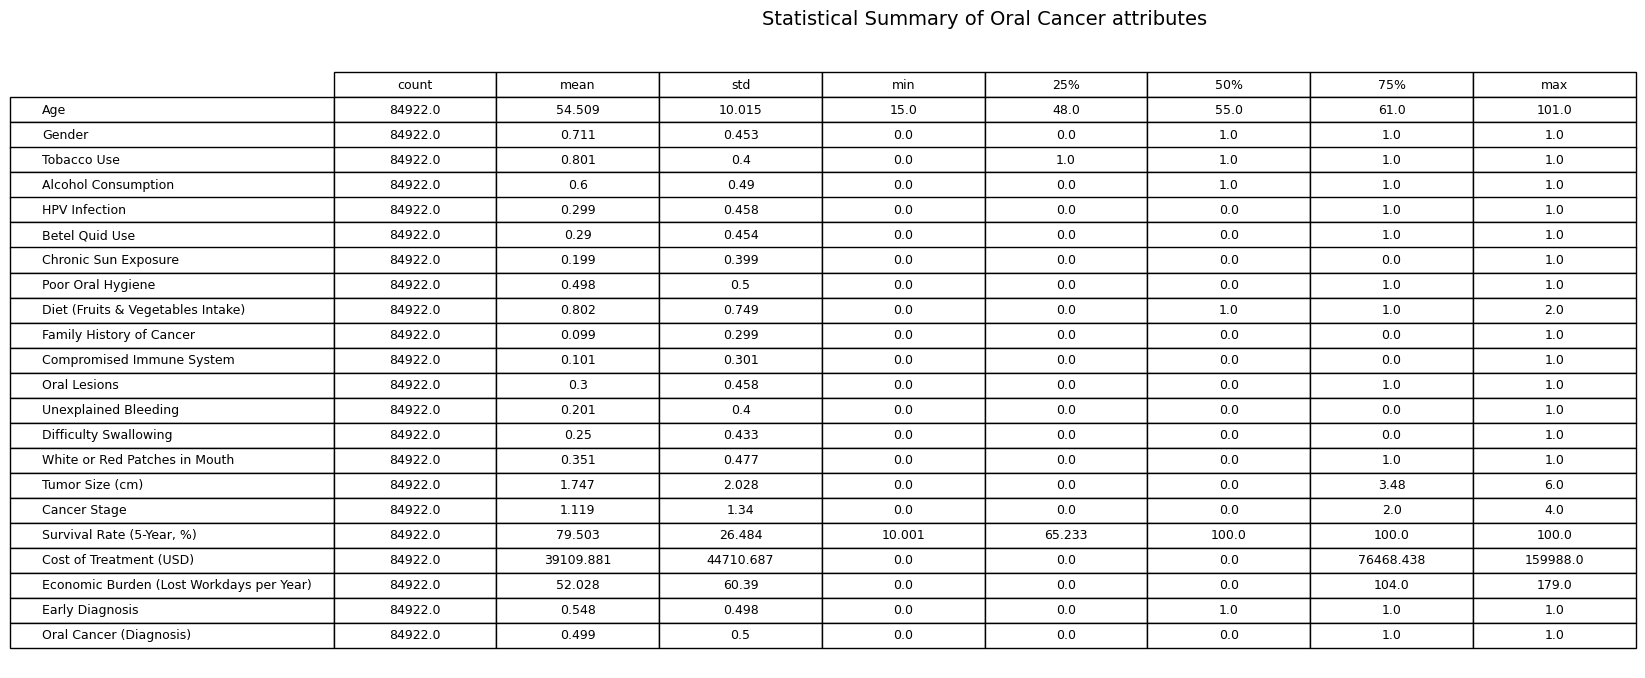

In [32]:
# --- STATISTICAL ANALYSIS --- Visualization (Table) ---

import pandas as pd
import matplotlib.pyplot as plt

# 1. Calculate descriptive statistics
# .T transposes it so variables are rows, making it easier to read if you have many columns
df_stats = df_risk.describe().T

# 2. Create the table visualization
fig, ax = plt.subplots(figsize=(14, 8)) # Adjusted size for medical datasets
ax.axis('off')

table = ax.table(cellText=df_stats.round(3).values,
                 rowLabels=df_stats.index,
                 colLabels=df_stats.columns,
                 cellLoc='center',
                 loc='center')

# 3. Styling for readability
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5) # Scale height for better row spacing

plt.title("Statistical Summary of Oral Cancer attributes", fontsize=14, pad=20)
plt.savefig('oral_cancer_summary_stats.png', bbox_inches='tight', dpi=300)
plt.show()

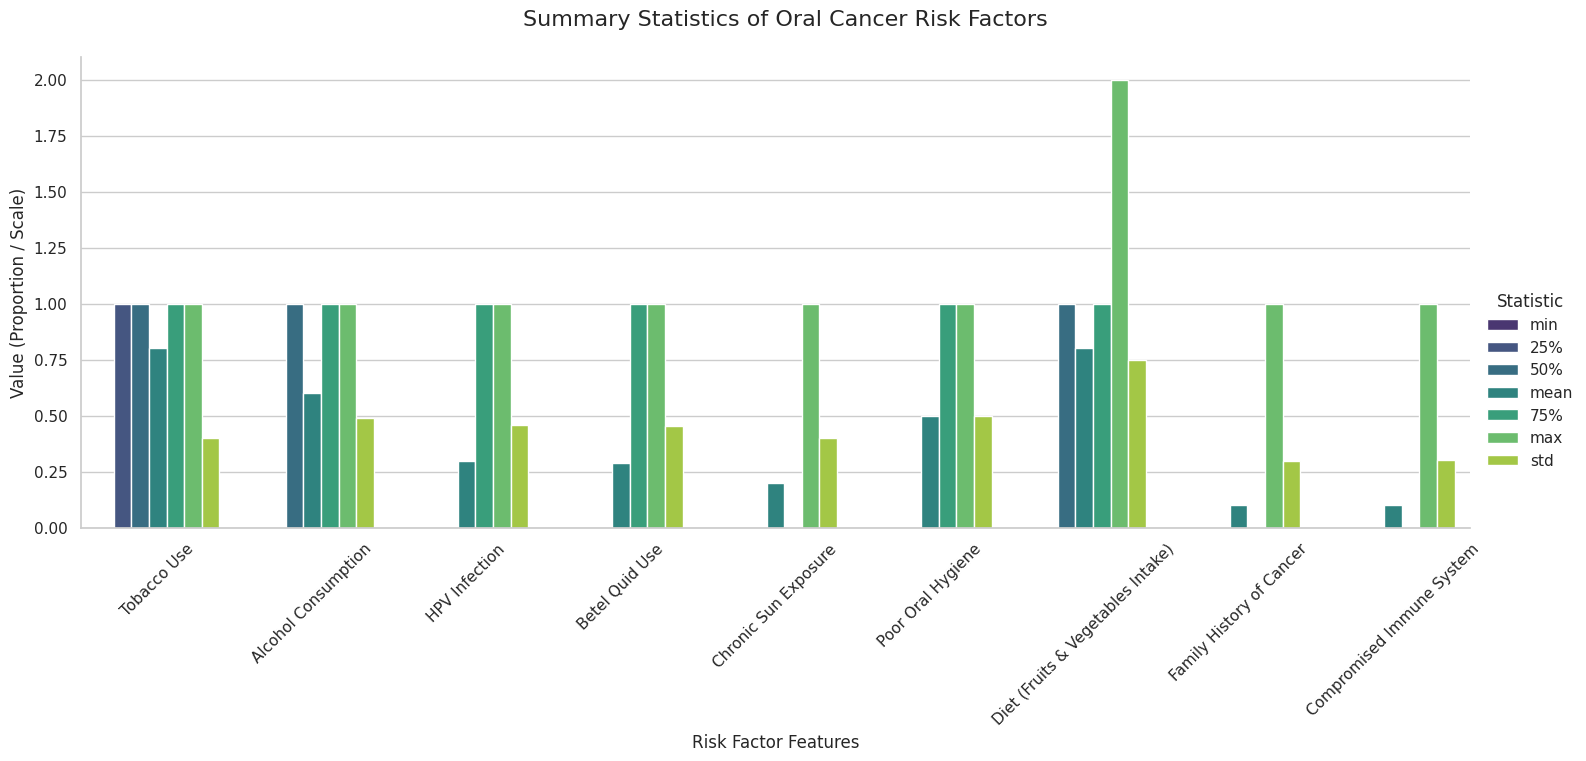

In [33]:
# --- STATISTICAL ANALYSIS --- Visualization (Bar Graph) ---

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select the specific risk factors to plot
# (We exclude Age because the values are on a much larger scale)
risk_factors_to_plot = [
    'Tobacco Use', 'Alcohol Consumption', 'HPV Infection', 'Betel Quid Use',
    'Chronic Sun Exposure', 'Poor Oral Hygiene', 'Diet (Fruits & Vegetables Intake)',
    'Family History of Cancer', 'Compromised Immune System'
]

# 2. Extract the summary statistics and transpose them
df_stats_plot = df_risk[risk_factors_to_plot].describe().loc[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]

# 3. Melt the DataFrame to long-form (required for seaborn.catplot)
df_melted = df_stats_plot.reset_index().melt(id_vars='index', var_name='Feature', value_name='Value')
df_melted.columns = ['Statistic', 'Feature', 'Value']

# 4. Set the categorical order for the statistics to match standard reporting
stat_order = ['min', '25%', '50%', 'mean', '75%', 'max', 'std']
df_melted['Statistic'] = pd.Categorical(df_melted['Statistic'], categories=stat_order, ordered=True)

# 5. Generate the grouped bar graph
sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=df_melted,
    x='Feature',
    y='Value',
    hue='Statistic',
    kind='bar',
    height=6,
    aspect=2.5,
    palette='viridis'
)

# 6. Final Styling
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Summary Statistics of Oral Cancer Risk Factors', fontsize=16)
plt.xlabel('Risk Factor Features', fontsize=12)
plt.ylabel('Value (Proportion / Scale)', fontsize=12)
plt.xticks(rotation=45)
g._legend.set_title('Statistic')

# 7. Save and show the output
plt.savefig('risk_factors_summary_bar_graph.png', dpi=300, bbox_inches='tight')
plt.show()

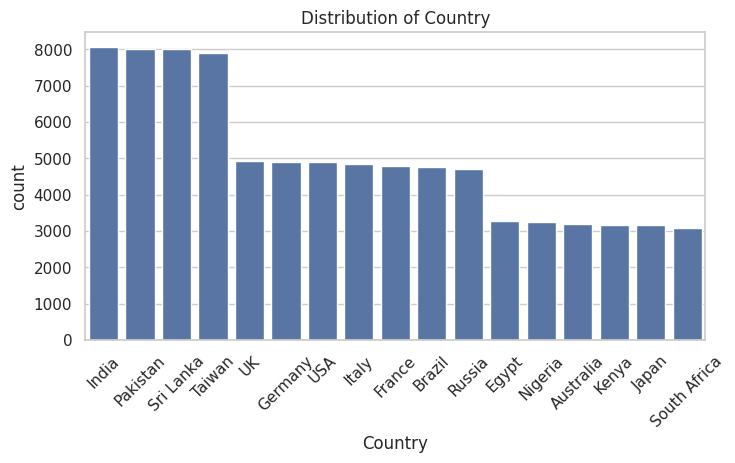

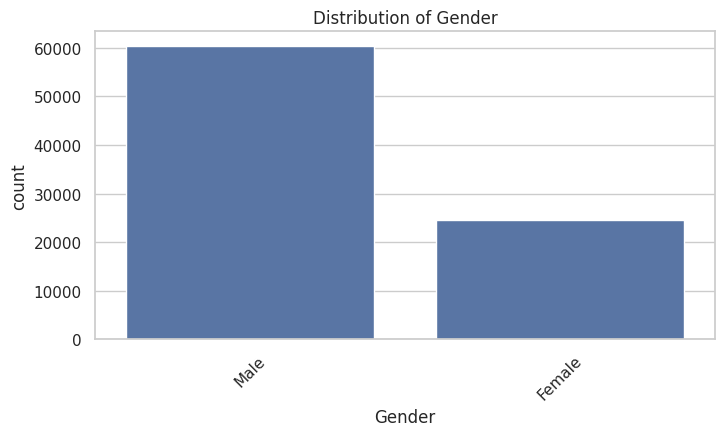

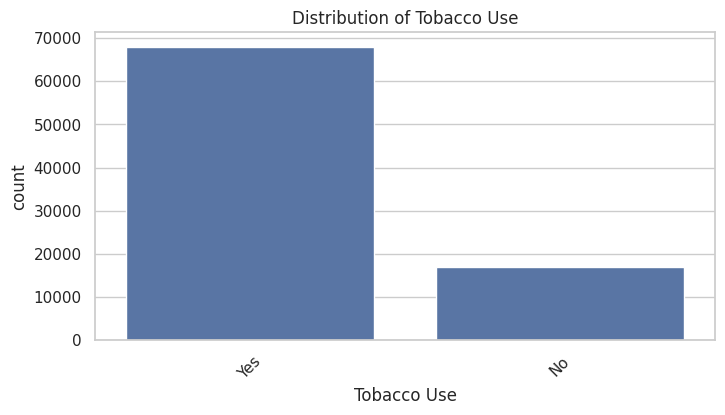

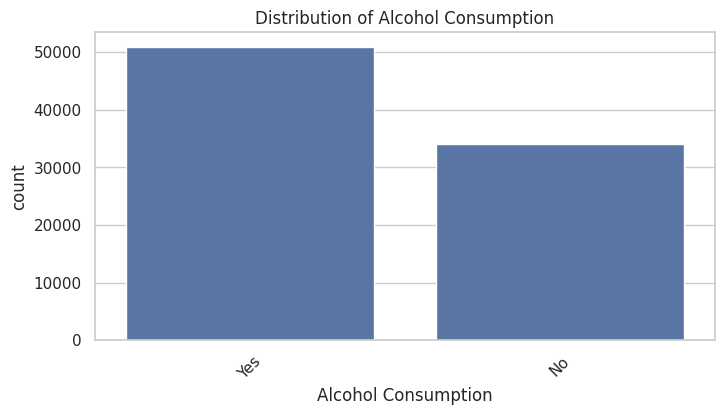

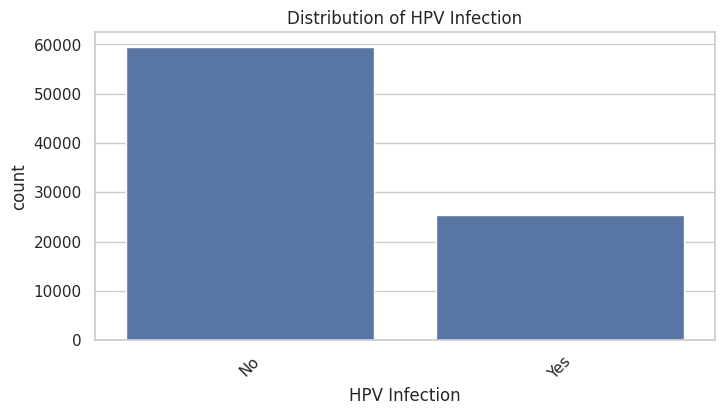

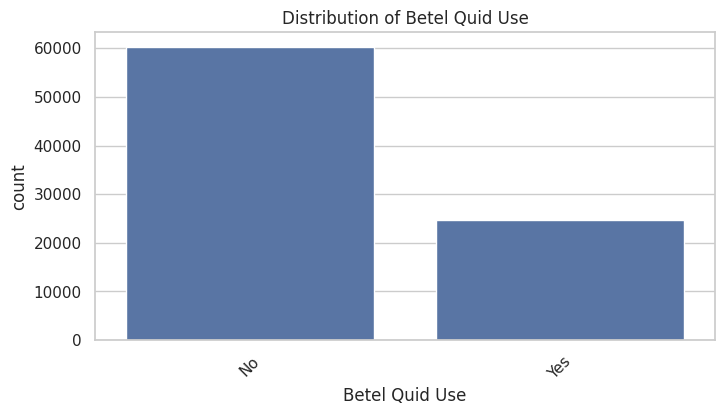

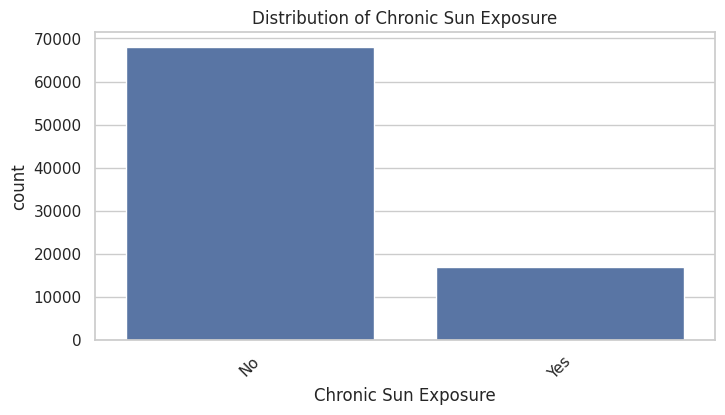

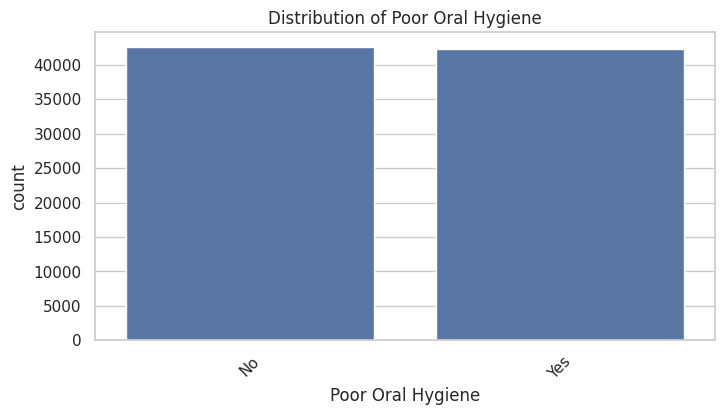

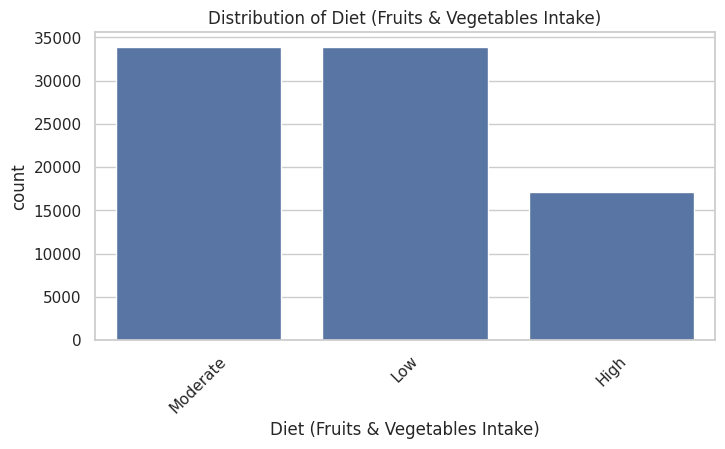

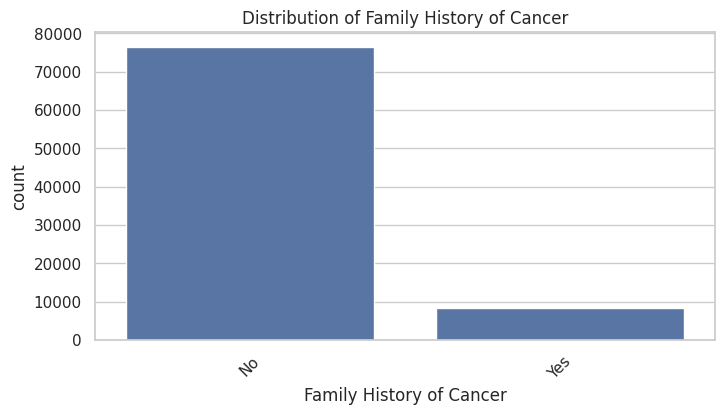

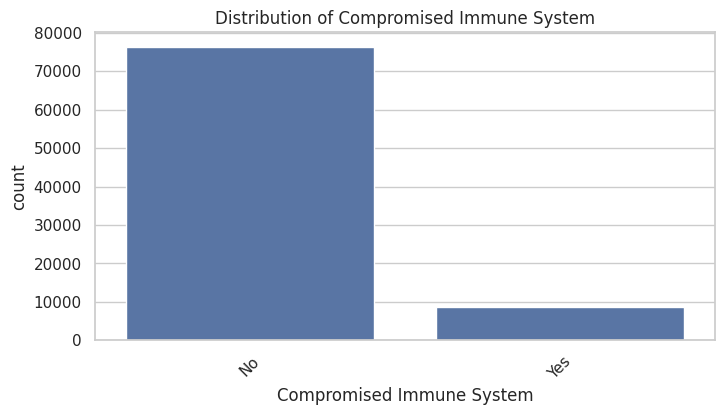

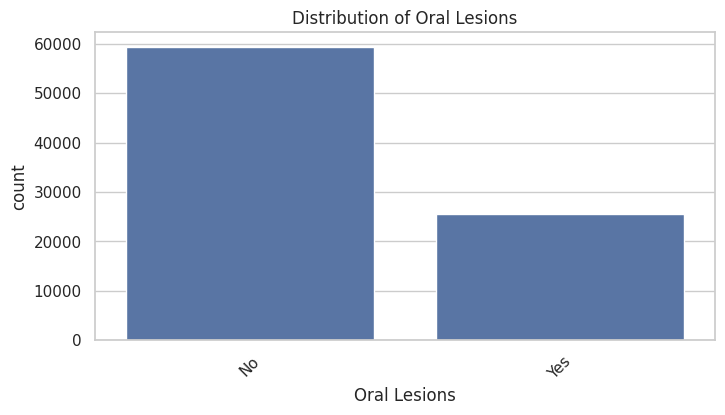

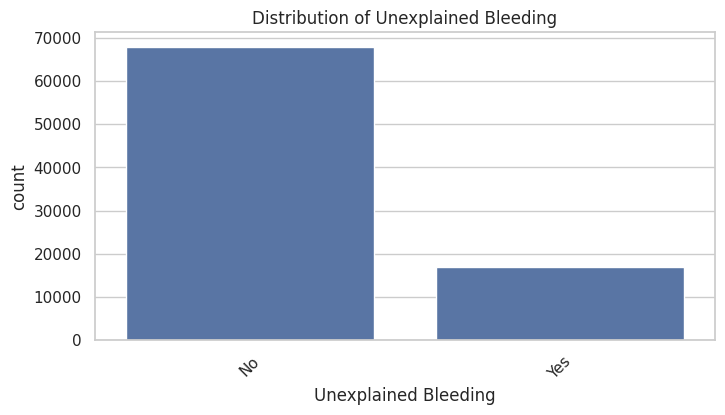

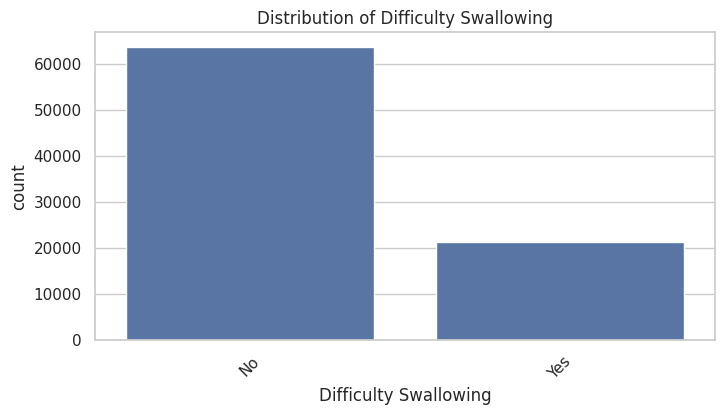

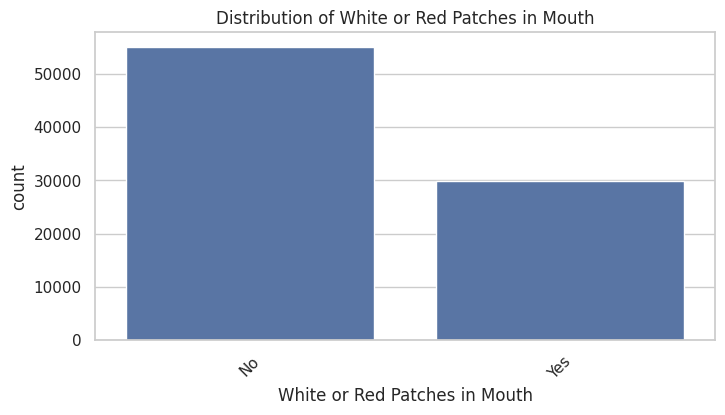

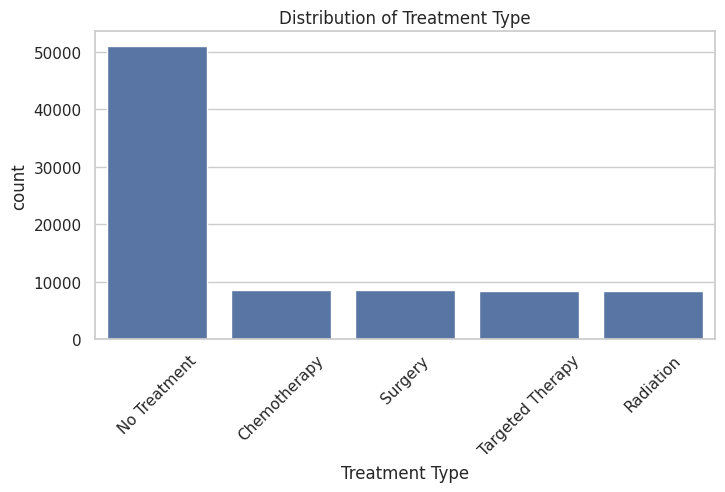

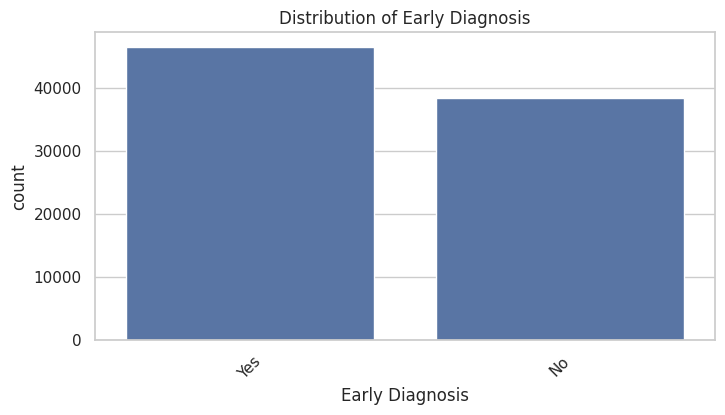

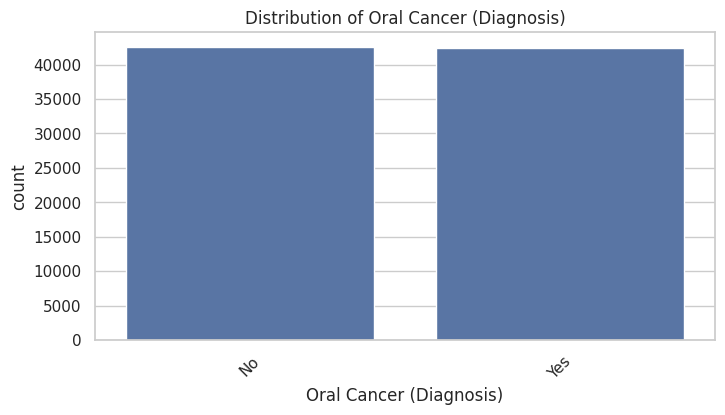

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(f"Distribution of {col}")
    plt.show()

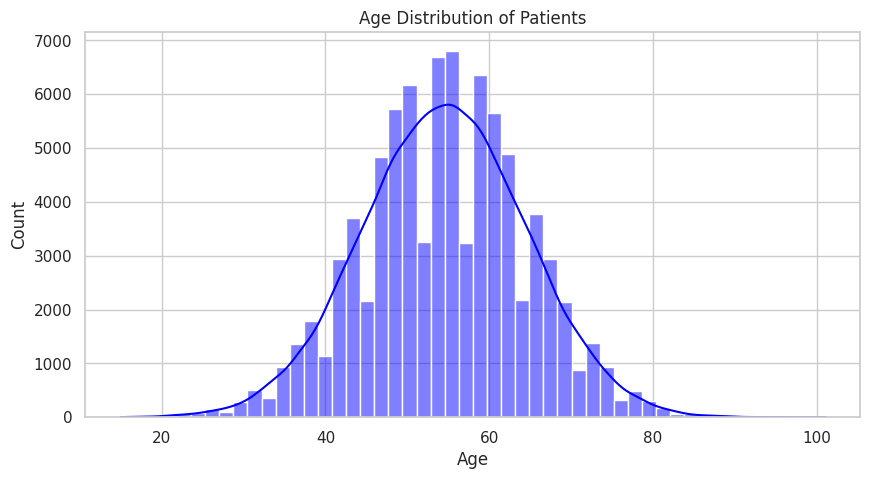

In [35]:
# Age Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df_risk["Age"], bins=50, kde=True, color="blue")
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Count")
plt.savefig('age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [36]:
import math

def plot_features_subplots(df, features, hue_col, plot_type='count', n_cols=3, figsize=(20, 15)):
    n_rows = math.ceil(len(features) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()

    for i, col in enumerate(features):
        if plot_type == 'count':
            sns.countplot(data=df, x=col, hue=hue_col, ax=axes[i])
            #axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
        elif plot_type == 'box':
            sns.boxplot(data=df, x=col, y=hue_col, ax=axes[i])
            #axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
        elif plot_type == 'histplot':
            sns.histplot(data=df, x=col, hue=hue_col, ax=axes[i],kde=True)
        axes[i].set_title(col)
        axes[i].legend(loc='upper right')
        axes[i].set_xlabel("")
        axes[i].set_ylabel("")
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


/tmp/ipykernel_15767/2102242005.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(loc='upper right')
/tmp/ipykernel_15767/2102242005.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(loc='upper right')
/tmp/ipykernel_15767/2102242005.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(loc='upper right')
/tmp/ipykernel_15767/2102242005.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(loc='upper right')
/tmp/ipykernel_15767

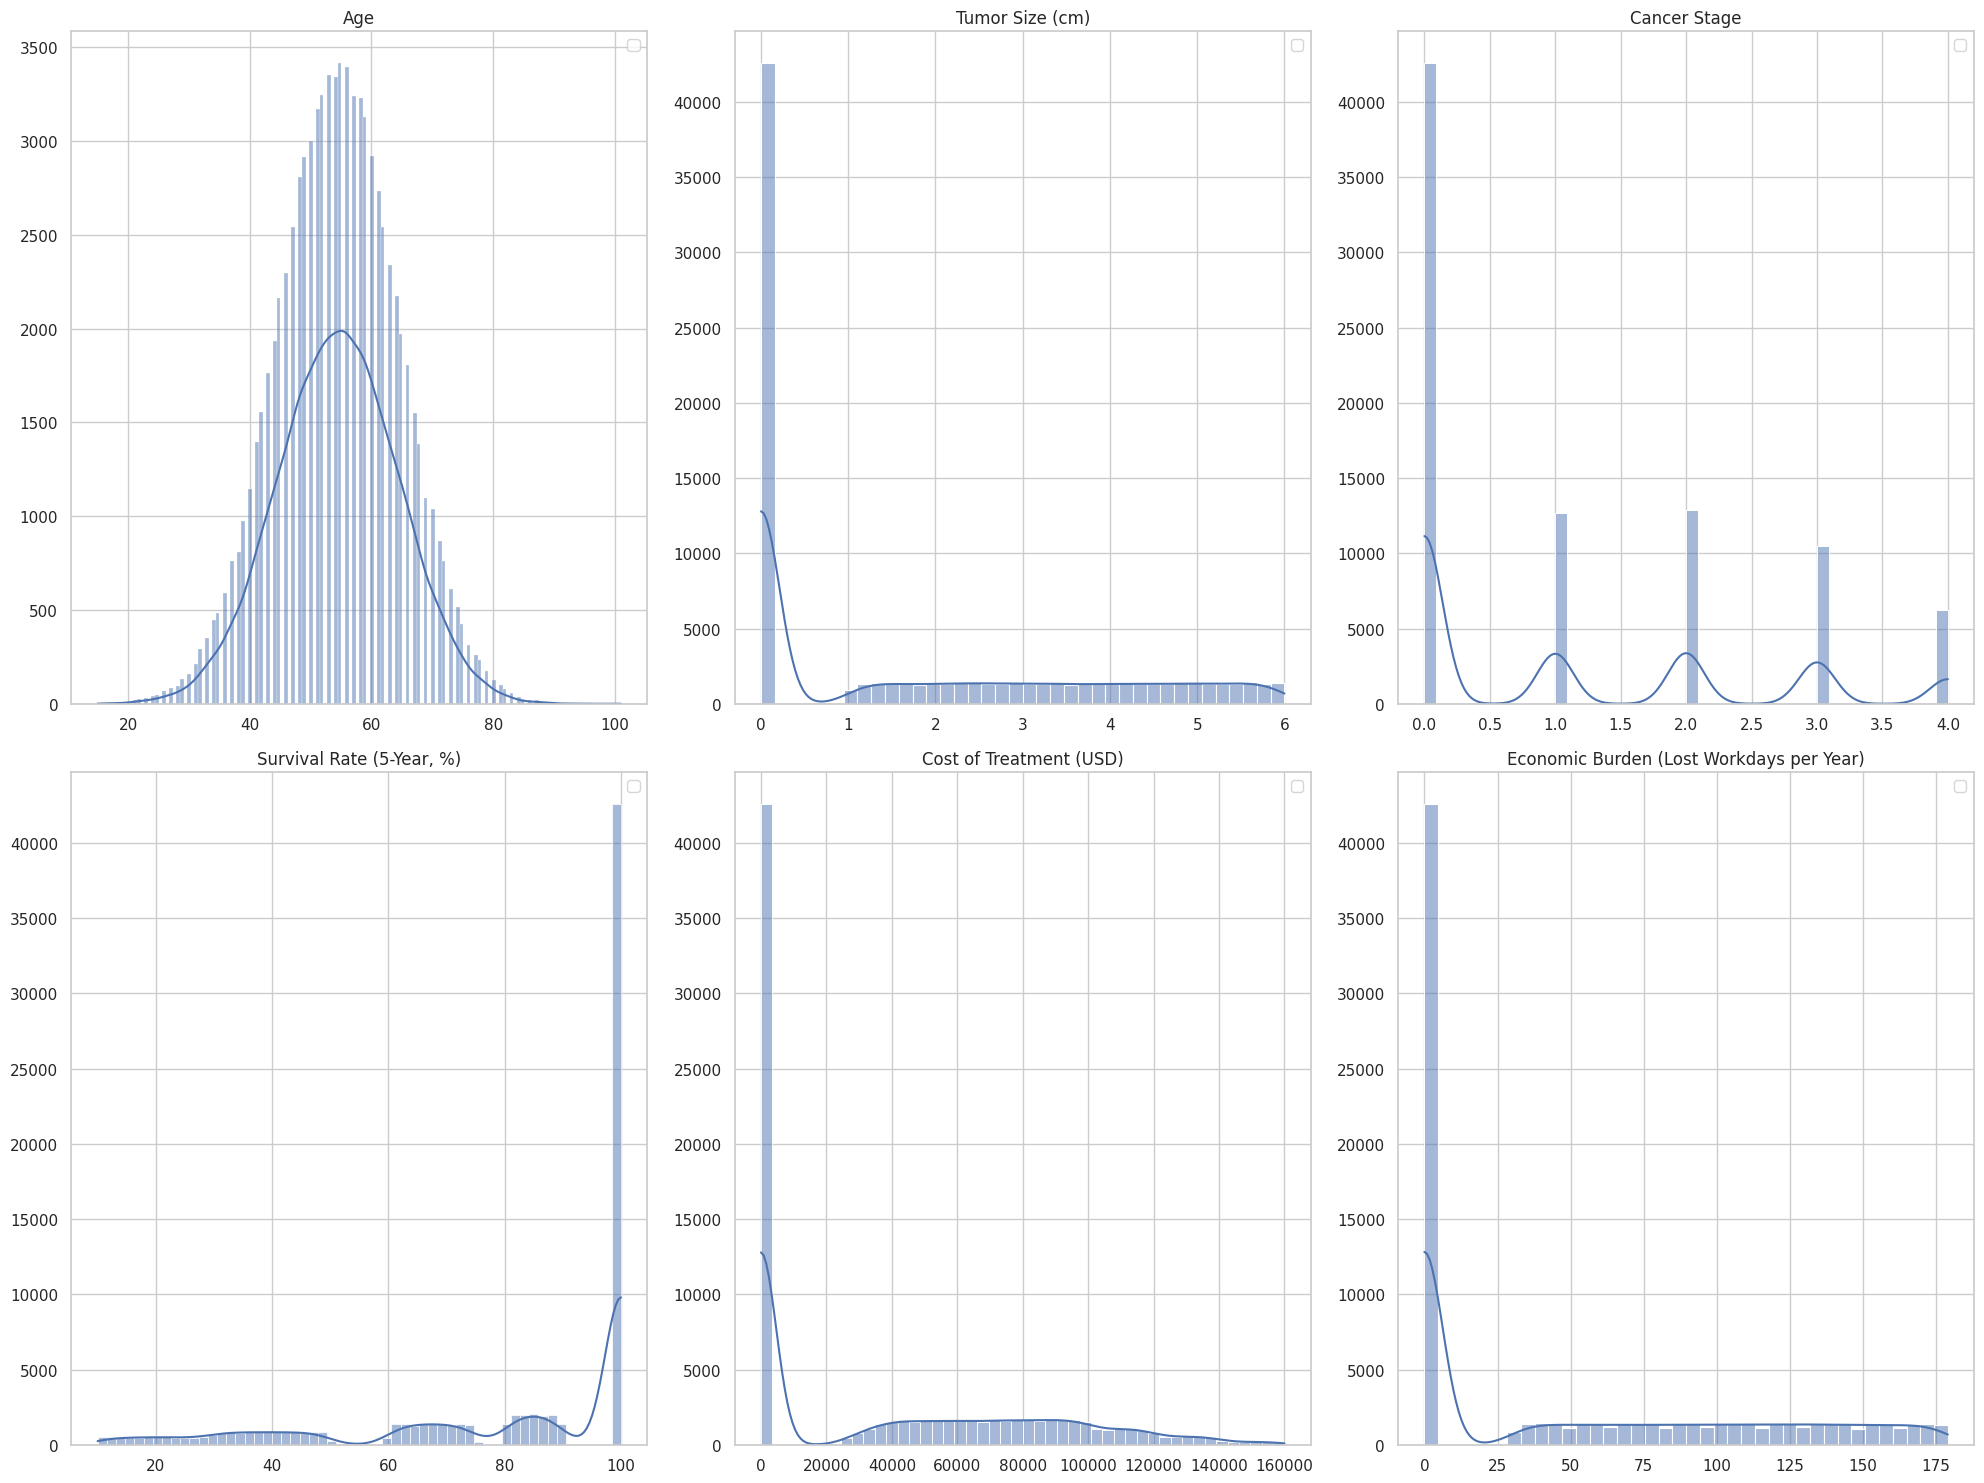

In [37]:
# plottig Distribution of Numeric Features
df=df.drop(columns=['ID'])
num_col = df.select_dtypes(include='number').columns
plot_features_subplots(df,features=num_col,hue_col=None,plot_type='histplot')

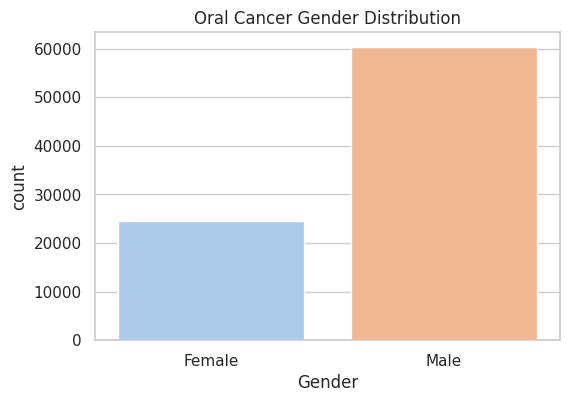

In [38]:
# 2. Oral Cancer Gender Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=df["Gender"], hue=df["Gender"], palette="pastel", legend=False)
plt.title("Oral Cancer Gender Distribution")
plt.show()

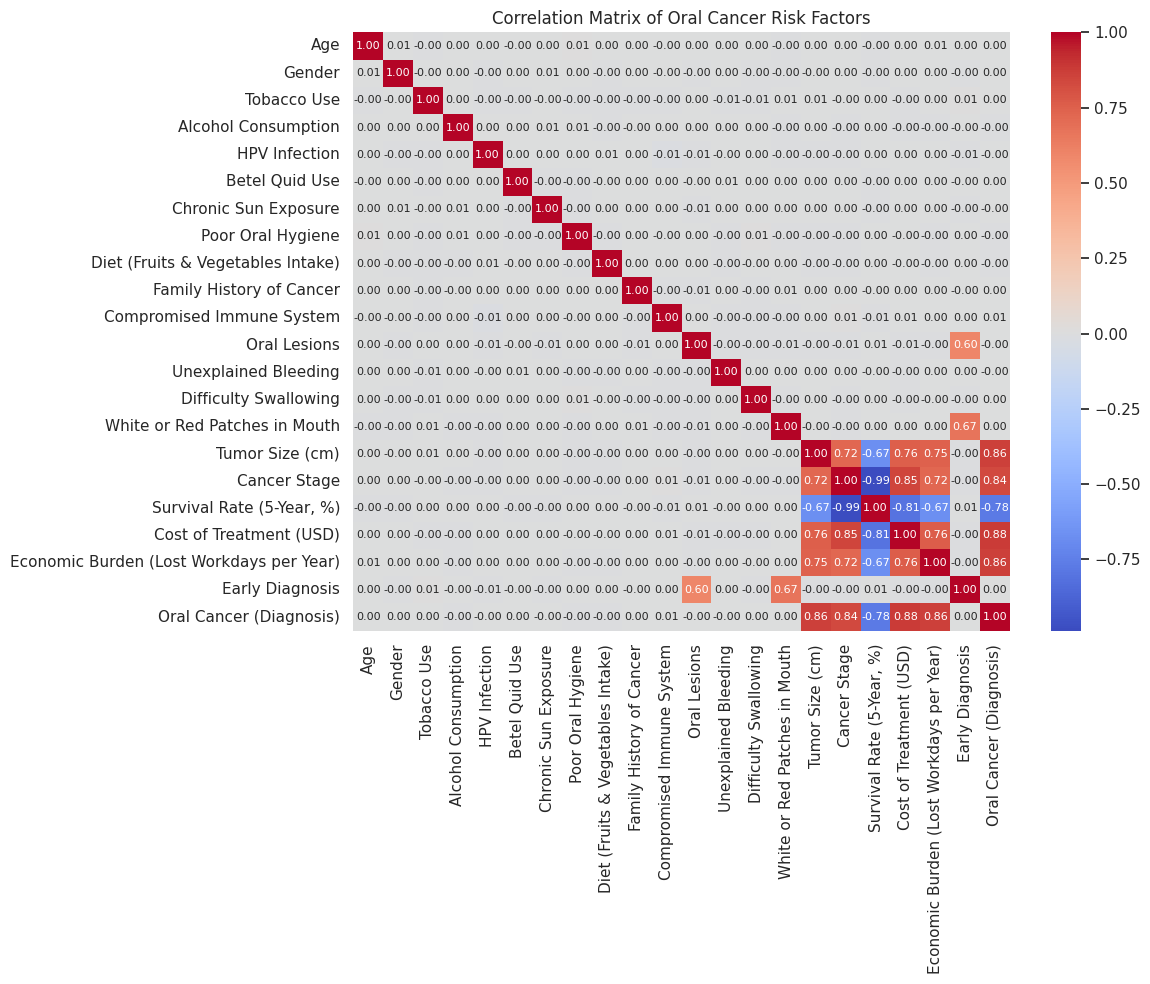

In [39]:


# --- SECTION 2: Correlation Matrix ---
plt.figure(figsize=(12, 10))
# Use df_risk instead of df, and ensure numeric_only is True
correlation_data = df_risk.corr(numeric_only=True)
sns.heatmap(correlation_data, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 8})
plt.title('Correlation Matrix of Oral Cancer Risk Factors')
plt.tight_layout()
plt.savefig('correlation_matrix_fixed.png', dpi=300)
plt.show()

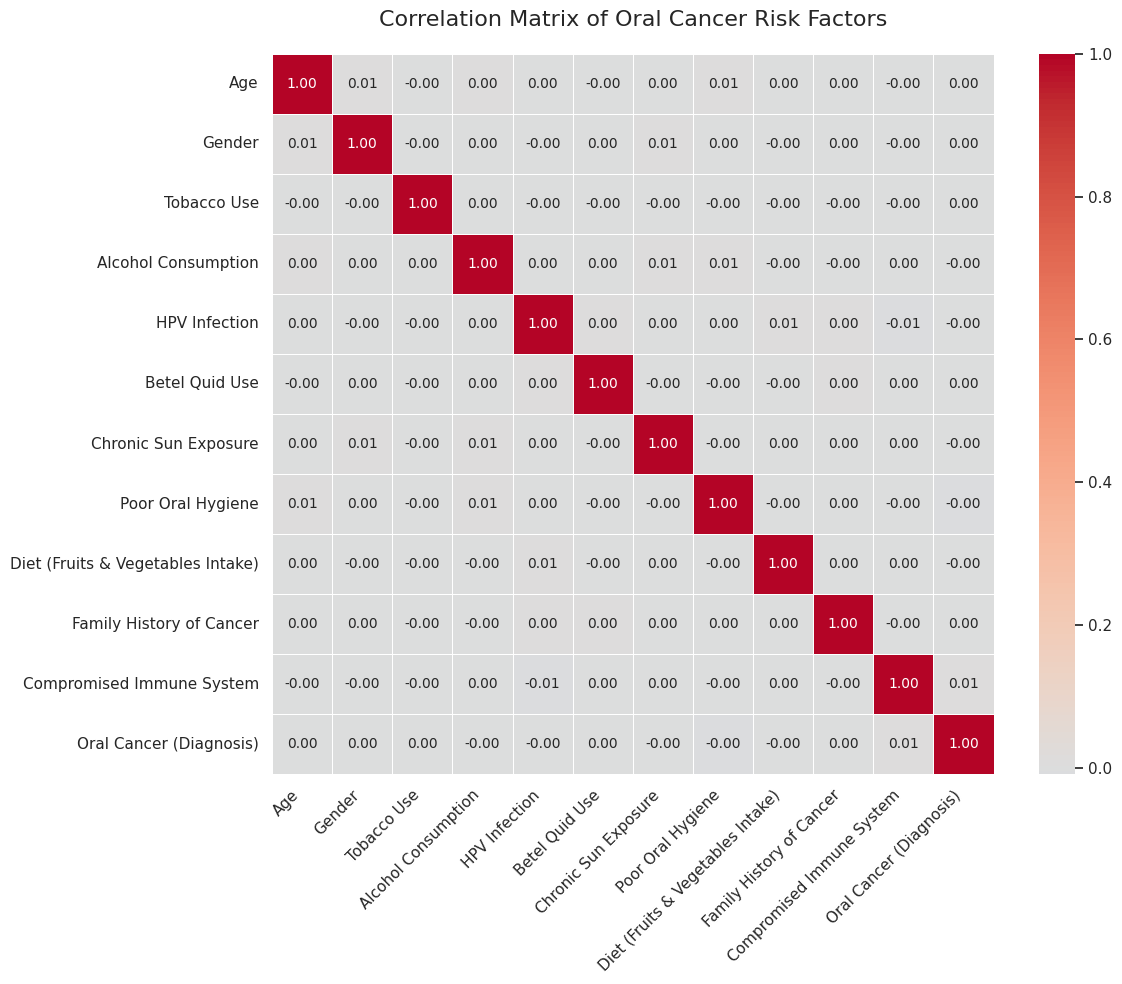


Top 3 Factors Correlated with Oral Cancer Diagnosis:
Compromised Immune System    0.005500
Age                          0.002308
Tobacco Use                  0.001896
Name: Oral Cancer (Diagnosis), dtype: float64


In [40]:
# --- SECTION 2: CORRELATION MATRIX (Risk Factors, Age, & Gender) ---

# 1. Define the specific risk factors to include in the correlation
# We include Age, Gender, and the lifestyle/biological factors
cols_for_correlation = [
    'Age', 'Gender', 'Tobacco Use', 'Alcohol Consumption',
    'HPV Infection', 'Betel Quid Use', 'Chronic Sun Exposure',
    'Poor Oral Hygiene', 'Diet (Fruits & Vegetables Intake)',
    'Family History of Cancer', 'Compromised Immune System',
    'Oral Cancer (Diagnosis)'
]

# 2. Calculate the correlation matrix
# Using numeric_only=True ensures we only process the numbers/mapped categories
corr_matrix = df_risk[cols_for_correlation].corr(numeric_only=True)

# 3. Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# 4. Generate the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,           # Display the correlation coefficients
    cmap='coolwarm',      # High positive = Red, High negative = Blue
    fmt=".2f",            # Format to 2 decimal places
    linewidths=0.5,
    center=0,             # Set 0 as the neutral point
    annot_kws={"size": 10}
)

# 5. Styling and Labels
plt.title('Correlation Matrix of Oral Cancer Risk Factors', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# 6. Save and show the output
plt.tight_layout()
plt.savefig('risk_factors_correlation_matrix.png', dpi=300)
plt.show()

# --- OPTIONAL: Print specific insights ---
print("\nTop 3 Factors Correlated with Oral Cancer Diagnosis:")
print(corr_matrix['Oral Cancer (Diagnosis)'].sort_values(ascending=False)[1:4])

Risk Score

In [41]:
df['Risk_Score'] = (
    df['Tobacco Use'].map({'Yes': 1, 'No': 0}) +
    df['HPV Infection'].map({'Yes': 1, 'No': 0}) +
    df['Alcohol Consumption'].map({'Yes': 1, 'No': 0}) +
    df['Betel Quid Use'].map({'Yes': 1, 'No': 0}) +
    df['Chronic Sun Exposure'].map({'Yes': 1, 'No': 0})+
      df['Compromised Immune System'].map({'Yes': 1, 'No': 0})+
    df['Poor Oral Hygiene'].map({'Yes': 1, 'No': 0})+
    df['Family History of Cancer'].map({'Yes': 1, 'No': 0})
)

Age Groups

In [42]:
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 30, 50, 70, 100], labels=['Young', 'Mid-age', 'Senior', 'Elderly'])

In [43]:
symptoms = ['Oral Lesions', 'Unexplained Bleeding', 'Difficulty Swallowing', 'White or Red Patches in Mouth']
df['Symptom_Count'] = df[symptoms].apply(lambda row: sum(row == 'Yes'), axis=1)

In [44]:
# convert Data types
df['Risk_Score']= df['Risk_Score'].astype('int')
df['Symptom_Count'] = df['Symptom_Count'].astype('int')
df['Age_Group'] = df['Age_Group'].astype('object')
df['Diet_Group'] =df['Diet (Fruits & Vegetables Intake)'].astype('object')

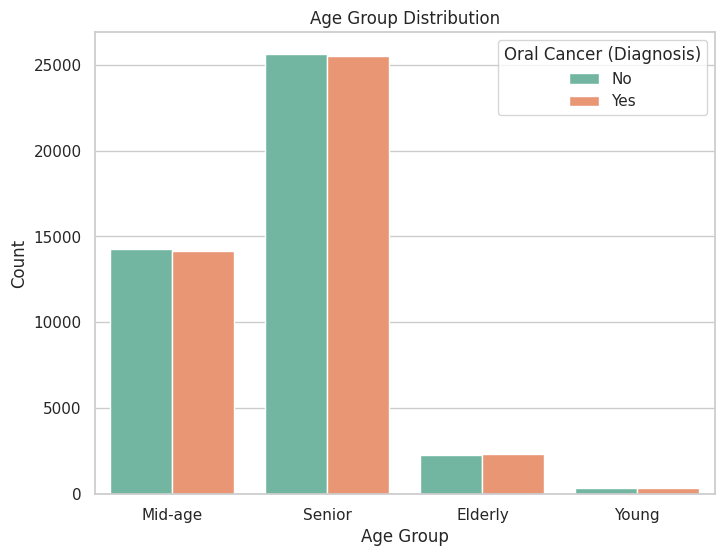

In [45]:
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='Age_Group',hue='Oral Cancer (Diagnosis)', palette='Set2')
plt.title('Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

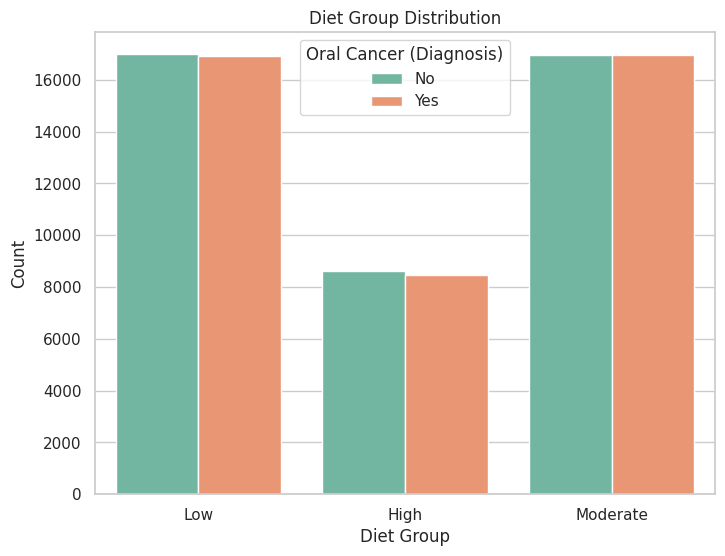

In [46]:
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='Diet_Group',hue='Oral Cancer (Diagnosis)', palette='Set2')
plt.title('Diet Group Distribution')
plt.xlabel('Diet Group')
plt.ylabel('Count')
plt.show()

In [47]:
import plotly.express as px
risk_diagnosis_counts = df.groupby(['Risk_Score', 'Oral Cancer (Diagnosis)']).size().reset_index(name='Count')

plt.figure(figsize=(12,6))
fig = px.bar(
    risk_diagnosis_counts,
    x='Risk_Score',
    y='Count',
    color='Oral Cancer (Diagnosis)',
    barmode='group',
    title='Number of Cancer Diagnosis (Yes/No) per Risk Score',
    labels={'Count': 'Number of Individuals', 'Risk Score': 'Risk Score'},
)

fig.update_layout(template='plotly_dark')
fig.show()

<Figure size 1200x600 with 0 Axes>

In [48]:
!pip install -U kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 3.6 MB/s eta 0:00:00


In [49]:
# 1. Install the missing image export dependency
!pip install -U kaleido

import plotly.express as px

# 2. Define the specific factors that make up the Risk_Score
risk_cols = [
    'Tobacco Use', 'Alcohol Consumption', 'HPV Infection', 'Betel Quid Use',
    'Chronic Sun Exposure', 'Poor Oral Hygiene', 'Family History of Cancer',
    'Compromised Immune System'
]

# 3. Filter for only patients with a "Yes" diagnosis
df_positive = df[df['Oral Cancer (Diagnosis)'] == 'Yes']

# 4. Calculate how many "Yes" values exist for each factor
risk_analysis = df_positive[risk_cols].apply(lambda x: (x == 'Yes').sum()).reset_index()
risk_analysis.columns = ['Risk Factor', 'Patient_Count']
risk_analysis = risk_analysis.sort_values(by='Patient_Count', ascending=False)

# 5. Create the Visualization
fig = px.bar(
    risk_analysis,
    x='Risk Factor',
    y='Patient_Count',
    text_auto='.2s',
    title='Most Common Risk Factors in Patients with Oral Cancer',
    color='Patient_Count',
    color_continuous_scale='Reds'
)

fig.update_layout(template='plotly_dark', xaxis_title="Specific Risk Factor", yaxis_title="Number of Patients")

# 6. Save the image (This will now work)


# 7. Show the plot
fig.show()

In [50]:
# Create a pivot table showing the % of 'Yes' for each factor at each Risk_Score level
heatmap_data = df[df['Oral Cancer (Diagnosis)'] == 'Yes'].groupby('Risk_Score')[risk_cols].apply(
    lambda x: (x == 'Yes').mean()
)

fig = px.imshow(
    heatmap_data,
    labels=dict(x="Risk Factor", y="Total Risk Score", color="Prevalence"),
    x=risk_cols,
    y=heatmap_data.index,
    title="Heatmap: Which Factors Contribute Most to Each Risk Score?",
    color_continuous_scale='Viridis'
)

fig.update_layout(template='plotly_dark')
fig.show()

In [51]:
risk_diagnosis_counts = df.groupby(['Symptom_Count', 'Oral Cancer (Diagnosis)']).size().reset_index(name='Count')

plt.figure(figsize=(12,6))
fig = px.bar(
    risk_diagnosis_counts,
    x='Symptom_Count',
    y='Count',
    color='Oral Cancer (Diagnosis)',
    barmode='group',
    title='Number of Cancer Diagnosis (Yes/No) per Symptom Count',
    labels={'Count': 'Number of Individuals', 'Symptom Count': 'Symptom Count'},
)

fig.update_layout(template='plotly_dark')
fig.show()

<Figure size 1200x600 with 0 Axes>

In [52]:
import plotly.express as px

# 1. Define the specific symptom columns
symptom_cols = [
    'Oral Lesions', 'Unexplained Bleeding', 'Difficulty Swallowing',
    'White or Red Patches in Mouth'
]

# 2. Filter for only patients with a "Yes" diagnosis
df_positive = df[df['Oral Cancer (Diagnosis)'] == 'Yes']

# 3. Calculate how many "Yes" values exist for each symptom
symptom_analysis = df_positive[symptom_cols].apply(lambda x: (x == 'Yes').sum()).reset_index()
symptom_analysis.columns = ['Symptom', 'Patient_Count']
symptom_analysis = symptom_analysis.sort_values(by='Patient_Count', ascending=False)

# 4. Visualize the specific symptoms
fig = px.bar(
    symptom_analysis,
    x='Symptom',
    y='Patient_Count',
    text_auto='.2s',
    title='Frequency of Specific Symptoms in Confirmed Oral Cancer Cases',
    color='Patient_Count',
    color_continuous_scale='Purples'  # Using Purples to distinguish from Risk Factors
)

fig.update_layout(
    template='plotly_dark',
    xaxis_title="Symptom Type",
    yaxis_title="Number of Patients",
    yaxis={'categoryorder':'total descending'}
)
fig.show()

In [53]:
df.head()

,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,Diet (Fruits & Vegetables Intake),...,Treatment Type,"Survival Rate (5-Year, %)",Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis),Risk_Score,Age_Group,Symptom_Count,Diet_Group
0,Italy,36,Female,Yes,Yes,Yes,No,No,Yes,Low,...,No Treatment,100.000000,0.00,0,No,No,4,Mid-age,0,Low
1,Japan,64,Male,Yes,Yes,Yes,No,Yes,Yes,High,...,No Treatment,83.340103,77772.50,177,No,Yes,5,Senior,1,High
2,UK,37,Female,No,Yes,No,No,Yes,Yes,Moderate,...,Surgery,63.222871,101164.50,130,Yes,Yes,3,Mid-age,1,Moderate
3,Sri Lanka,55,Male,Yes,Yes,No,Yes,No,Yes,Moderate,...,No Treatment,100.000000,0.00,0,Yes,No,4,Senior,1,Moderate
4,South Africa,68,Male,No,No,No,No,No,Yes,High,...,No Treatment,44.293199,45354.75,52,No,Yes,1,Senior,0,High


In [54]:
cols_to_remove = ['Country','Age','Diet (Fruits & Vegetables Intake)',
                  'Family History of Cancer','Survival Rate (5-Year, %)',
                  'Cost of Treatment (USD)', 'Economic Burden (Lost Workdays per Year)'
                  ,'Cancer Stage','Treatment Type','Early Diagnosis']

df_model = df.drop(columns=cols_to_remove, errors='ignore')

In [55]:
df_model .head()

,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,Compromised Immune System,Oral Lesions,Unexplained Bleeding,Difficulty Swallowing,White or Red Patches in Mouth,Tumor Size (cm),Oral Cancer (Diagnosis),Risk_Score,Age_Group,Symptom_Count,Diet_Group
0,Female,Yes,Yes,Yes,No,No,Yes,No,No,No,No,No,0.000000,No,4,Mid-age,0,Low
1,Male,Yes,Yes,Yes,No,Yes,Yes,No,No,Yes,No,No,1.782186,Yes,5,Senior,1,High
2,Female,No,Yes,No,No,Yes,Yes,No,No,No,No,Yes,3.523895,Yes,3,Mid-age,1,Moderate
3,Male,Yes,Yes,No,Yes,No,Yes,No,Yes,No,No,No,0.000000,No,4,Senior,1,Moderate
4,Male,No,No,No,No,No,Yes,No,No,No,No,No,2.834789,Yes,1,Senior,0,High


In [56]:
#make sure the target variable is the last column and the rest of the columns are features
df_model  = df_model[[col for col in df_model .columns if col != 'Oral Cancer (Diagnosis)'] + ['Oral Cancer (Diagnosis)']]
df_model.head()

,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,Compromised Immune System,Oral Lesions,Unexplained Bleeding,Difficulty Swallowing,White or Red Patches in Mouth,Tumor Size (cm),Risk_Score,Age_Group,Symptom_Count,Diet_Group,Oral Cancer (Diagnosis)
0,Female,Yes,Yes,Yes,No,No,Yes,No,No,No,No,No,0.000000,4,Mid-age,0,Low,No
1,Male,Yes,Yes,Yes,No,Yes,Yes,No,No,Yes,No,No,1.782186,5,Senior,1,High,Yes
2,Female,No,Yes,No,No,Yes,Yes,No,No,No,No,Yes,3.523895,3,Mid-age,1,Moderate,Yes
3,Male,Yes,Yes,No,Yes,No,Yes,No,Yes,No,No,No,0.000000,4,Senior,1,Moderate,No
4,Male,No,No,No,No,No,Yes,No,No,No,No,No,2.834789,1,Senior,0,High,Yes


In [57]:
from sklearn.preprocessing import LabelEncoder
encoders = {}

for col in df_model.drop(columns=['Symptom_Count','Risk_Score']).columns:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df[col])
    encoders[col] = le

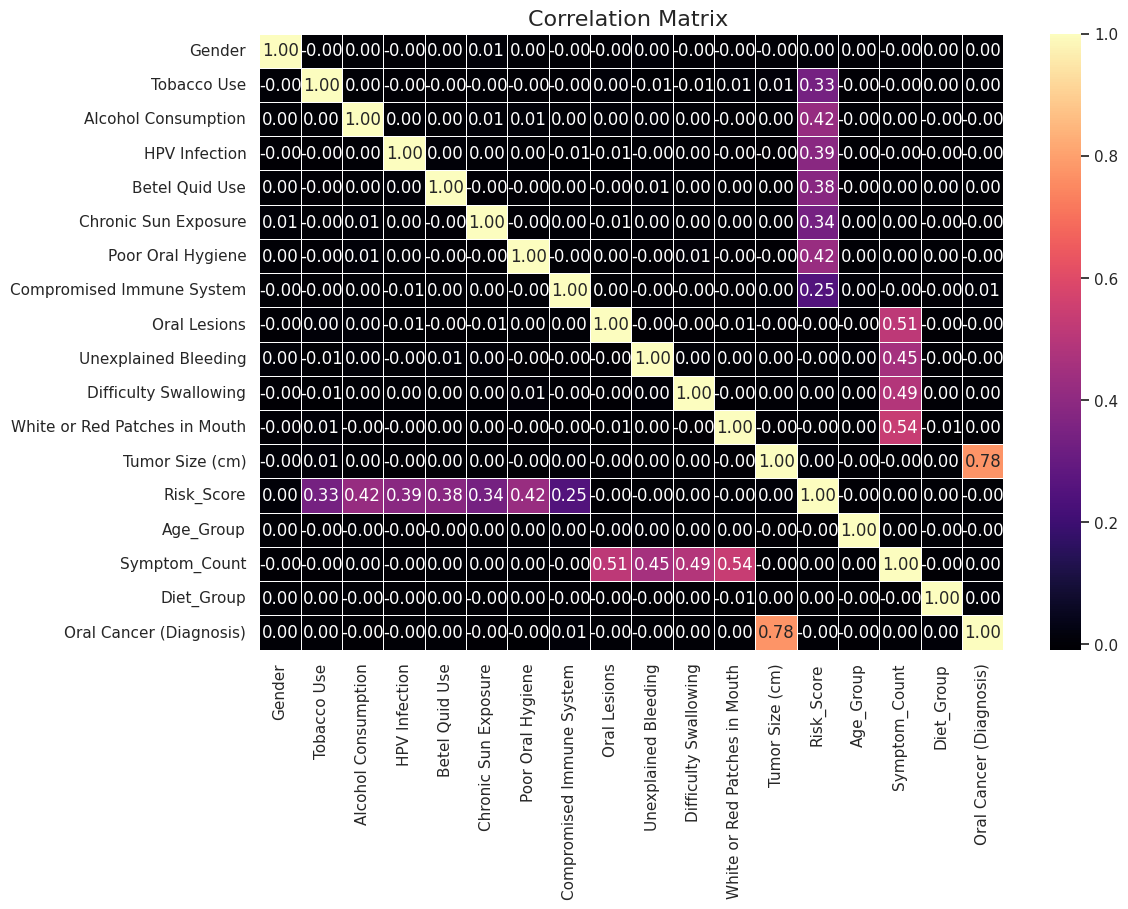

In [58]:
numeric_df = df_model.select_dtypes(include=['number'])
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="magma", linewidths=0.5)
plt.title("Correlation Matrix ", fontsize=16)
plt.show()

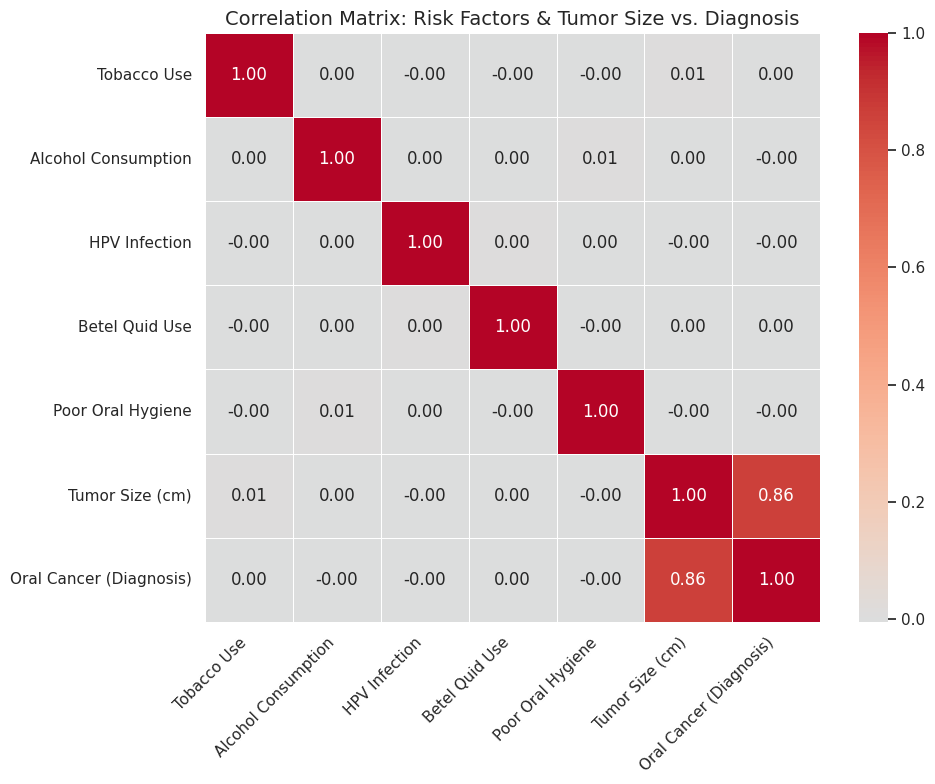

In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define the specific factors you want to analyze
factors_to_correlate = [
    'Tobacco Use',
    'Alcohol Consumption',
    'HPV Infection',
    'Betel Quid Use',
    'Poor Oral Hygiene',
    'Tumor Size (cm)',
    'Oral Cancer (Diagnosis)'
]

# 2. Create a copy of the data with only these columns
df_subset = df[factors_to_correlate].copy()

# 3. Map categorical 'Yes'/'No' to numeric 1/0
# This is required for the correlation math to work
binary_map = {'Yes': 1, 'No': 0}
categorical_cols = [
    'Tobacco Use', 'Alcohol Consumption', 'HPV Infection',
    'Betel Quid Use', 'Poor Oral Hygiene', 'Oral Cancer (Diagnosis)'
]

for col in categorical_cols:
    df_subset[col] = df_subset[col].map(binary_map)

# 4. Calculate the Correlation Matrix
corr_matrix = df_subset.corr()

# 5. Visualize the Matrix using a Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,          # Displays the correlation value in each cell
    cmap='coolwarm',     # Red for positive, Blue for negative correlation
    fmt=".2f",           # Round to 2 decimal places
    linewidths=0.5,
    center=0
)

plt.title('Correlation Matrix: Risk Factors & Tumor Size vs. Diagnosis', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

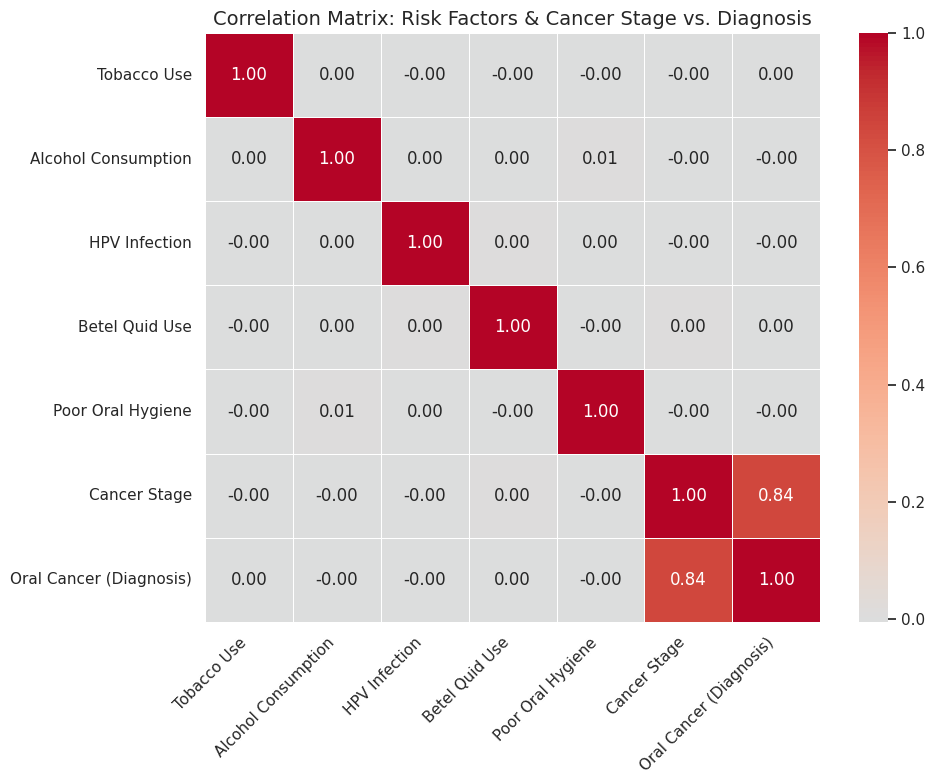

In [60]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define the specific factors you want to analyze (Replacing Tumor Size with Cancer Stage)
factors_to_correlate = [
    'Tobacco Use',
    'Alcohol Consumption',
    'HPV Infection',
    'Betel Quid Use',
    'Poor Oral Hygiene',
    'Cancer Stage',          # New column added here
    'Oral Cancer (Diagnosis)'
]

# 2. Create a copy of the data with only these columns
df_subset = df[factors_to_correlate].copy()

# 3. Map categorical 'Yes'/'No' to numeric 1/0
# This is required for the correlation math to work
binary_map = {'Yes': 1, 'No': 0}
categorical_cols = [
    'Tobacco Use', 'Alcohol Consumption', 'HPV Infection',
    'Betel Quid Use', 'Poor Oral Hygiene', 'Oral Cancer (Diagnosis)'
]

for col in categorical_cols:
    df_subset[col] = df_subset[col].map(binary_map)

# Note: 'Cancer Stage' is already numeric (0, 1, 2, 3, 4) in your dataset,
# so it does not need a map.

# 4. Calculate the Correlation Matrix
corr_matrix = df_subset.corr()

# 5. Visualize the Matrix using a Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,          # Displays the correlation value in each cell
    cmap='coolwarm',     # Red for positive, Blue for negative correlation
    fmt=".2f",           # Round to 2 decimal places
    linewidths=0.5,
    center=0
)

plt.title('Correlation Matrix: Risk Factors & Cancer Stage vs. Diagnosis', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save the file so you can download it from the sidebar
plt.savefig('correlation_matrix_stage.png', dpi=300)

plt.show()

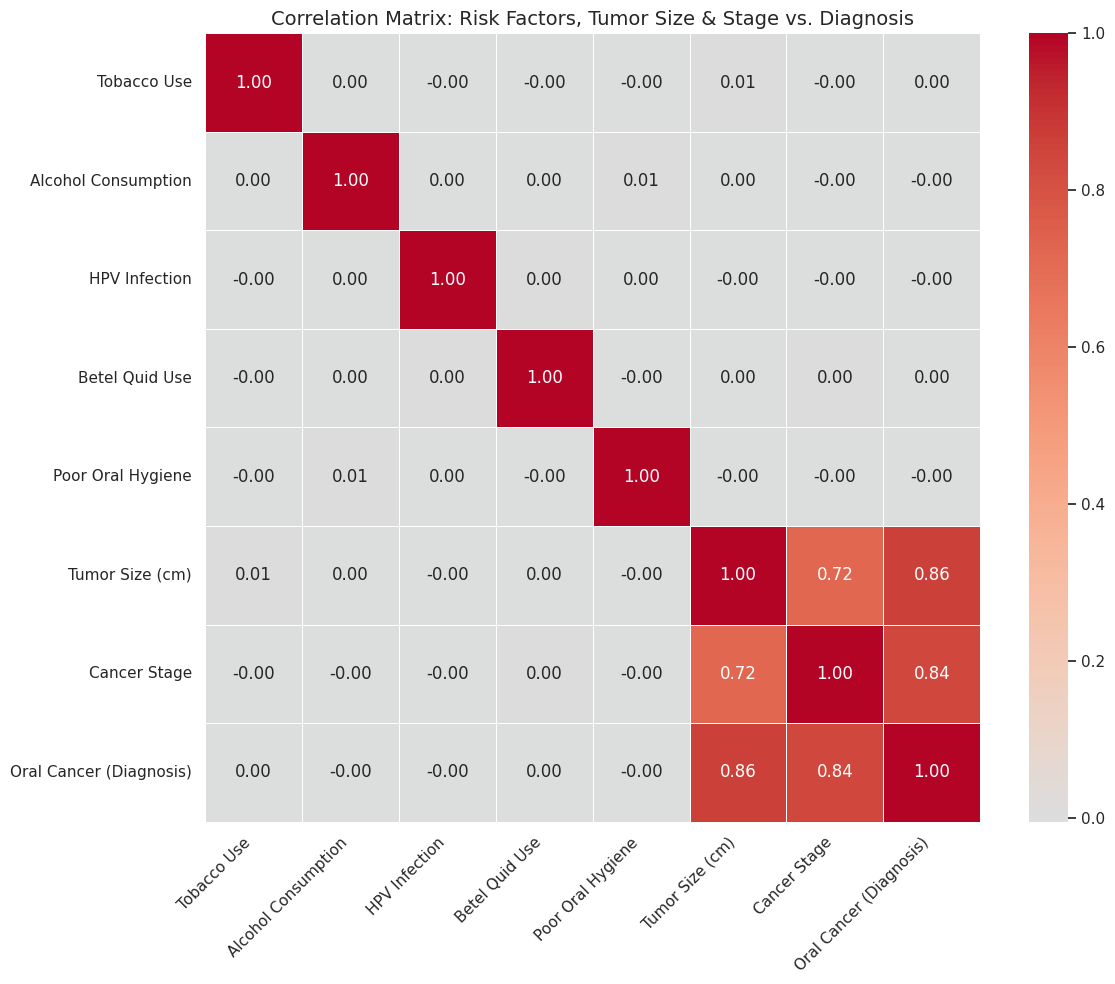

In [61]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define the complete set of factors to analyze
factors_to_correlate = [
    'Tobacco Use',
    'Alcohol Consumption',
    'HPV Infection',
    'Betel Quid Use',
    'Poor Oral Hygiene',
    'Tumor Size (cm)',       # Added back
    'Cancer Stage',          # Retained
    'Oral Cancer (Diagnosis)'
]

# 2. Prepare the dataset subset
df_subset = df[factors_to_correlate].copy()

# 3. Map categorical columns (Yes/No) to numeric (1/0)
binary_map = {'Yes': 1, 'No': 0}
categorical_cols = [
    'Tobacco Use', 'Alcohol Consumption', 'HPV Infection',
    'Betel Quid Use', 'Poor Oral Hygiene', 'Oral Cancer (Diagnosis)'
]

for col in categorical_cols:
    df_subset[col] = df_subset[col].map(binary_map)

# 4. Calculate the Correlation Matrix
corr_matrix = df_subset.corr()

# 5. Visualize the Matrix using a Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    center=0
)

plt.title('Correlation Matrix: Risk Factors, Tumor Size & Stage vs. Diagnosis', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save the high-resolution image to your Colab folder
plt.savefig('correlation_matrix_comprehensive.png', dpi=300)
plt.show()

Risk Analysis Summary:
Total Patients: 84922
Probability of Oral Cancer (P): 0.4987
Probability of Normal State (P): 0.5013


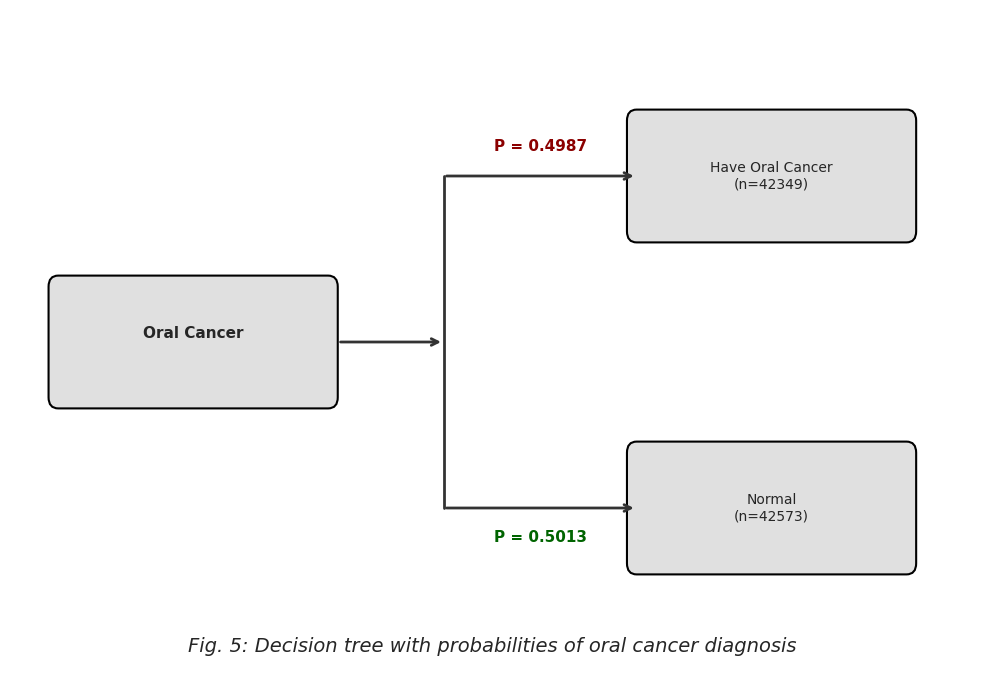

In [62]:
# --- SECTION 3: RISK ANALYSIS - DECISION TREE ---
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Calculate Probabilities
total_records = len(df)
# In df_risk, 'Oral Cancer (Diagnosis)' was mapped: Yes=1, No=0
yes_count = df_risk['Oral Cancer (Diagnosis)'].sum()
no_count = total_records - yes_count

p_yes = yes_count / total_records
p_no = no_count / total_records

print(f"Risk Analysis Summary:")
print(f"Total Patients: {total_records}")
print(f"Probability of Oral Cancer (P): {p_yes:.4f}")
print(f"Probability of Normal State (P): {p_no:.4f}")

# 2. Create the Decision Tree Visualization
fig, ax = plt.subplots(figsize=(10, 7))

# Set limits and remove axes
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')

# Box styling
box_width = 2.8
box_height = 1.0
rect_kwargs = dict(edgecolor='black', facecolor='#e0e0e0', lw=1.5, zorder=2)

# Root Box (Left)
root_box = patches.FancyBboxPatch((0.5, 2.5), box_width, box_height, boxstyle="round,pad=0.1", **rect_kwargs)
ax.add_patch(root_box)
ax.text(0.5 + box_width/2, 2.5 + box_height/2, 'Oral Cancer\n', ha='center', va='center', fontsize=11, fontweight='bold')

# Outcome Boxes (Right)
# Upper box: Have Oral Cancer
upper_box = patches.FancyBboxPatch((6.5, 4.0), box_width, box_height, boxstyle="round,pad=0.1", **rect_kwargs)
ax.add_patch(upper_box)
ax.text(6.5 + box_width/2, 4.0 + box_height/2, f'Have Oral Cancer\n(n={yes_count})', ha='center', va='center', fontsize=10)

# Lower box: Normal
lower_box = patches.FancyBboxPatch((6.5, 1.0), box_width, box_height, boxstyle="round,pad=0.1", **rect_kwargs)
ax.add_patch(lower_box)
ax.text(6.5 + box_width/2, 1.0 + box_height/2, f'Normal\n(n={no_count})', ha='center', va='center', fontsize=10)

# Connectors (Arrows and Lines)
# Main stem from root
ax.annotate('', xy=(4.5, 3.0), xytext=(3.4, 3.0), arrowprops=dict(arrowstyle='->', lw=2, color='#333333'))

# Vertical split line
ax.plot([4.5, 4.5], [1.5, 4.5], color='#333333', lw=2)

# Horizontal branches to outcomes
ax.annotate('', xy=(6.5, 4.5), xytext=(4.5, 4.5), arrowprops=dict(arrowstyle='->', lw=2, color='#333333'))
ax.annotate('', xy=(6.5, 1.5), xytext=(4.5, 1.5), arrowprops=dict(arrowstyle='->', lw=2, color='#333333'))

# Probability Labels
ax.text(5.5, 4.7, f'P = {p_yes:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold', color='darkred')
ax.text(5.5, 1.3, f'P = {p_no:.4f}', ha='center', va='top', fontsize=11, fontweight='bold', color='darkgreen')

# Title and Layout
plt.title('Fig. 5: Decision tree with probabilities of oral cancer diagnosis', y=0.02, fontsize=14, fontstyle='italic')
plt.tight_layout()

# 3. Save and show
plt.savefig('oral_cancer_decision_tree.png', dpi=300, bbox_inches='tight')
plt.show()

In [63]:
import pandas as pd

# Load the dataset

df.columns = df.columns.str.strip()

# total records for probability calculation
N = len(df)

# Define the Basic Events
events = {
    "Age > 50": (df['Age'] > 50),
    "Gender: Male": (df['Gender'].str.strip() == 'Male'),
    "Tobacco Use: Yes": (df['Tobacco Use'].str.strip() == 'Yes'),
    "Alcohol Consumption: Yes": (df['Alcohol Consumption'].str.strip() == 'Yes'),
    "HPV Infection: Yes": (df['HPV Infection'].str.strip() == 'Yes'),
    "Betel Quid Use: Yes": (df['Betel Quid Use'].str.strip() == 'Yes'),
    "Chronic Sun Exposure: Yes": (df['Chronic Sun Exposure'].str.strip() == 'Yes'),
    "Poor Oral Hygiene: Yes": (df['Poor Oral Hygiene'].str.strip() == 'Yes'),
    "Family History: Yes": (df['Family History of Cancer'].str.strip() == 'Yes'),
    "Compromised Immune: Yes": (df['Compromised Immune System'].str.strip() == 'Yes'),
    "Oral Lesions: Yes": (df['Oral Lesions'].str.strip() == 'Yes'),
    "Unexplained Bleeding: Yes": (df['Unexplained Bleeding'].str.strip() == 'Yes'),
    "Difficulty Swallowing: Yes": (df['Difficulty Swallowing'].str.strip() == 'Yes'),
    "White/Red Patches: Yes": (df['White or Red Patches in Mouth'].str.strip() == 'Yes')
}

print(f"{'Basic Event':<35} | {'Count':<10} | {'Probability'}")
print("-" * 60)

for name, mask in events.items():
    count = mask.sum()
    prob = count / N
    print(f"{name:<35} | {count:<10} | {prob:.4f}")

Basic Event                         | Count      | Probability
------------------------------------------------------------
Age > 50                            | 55756      | 0.6566
Gender: Male                        | 60351      | 0.7107
Tobacco Use: Yes                    | 67989      | 0.8006
Alcohol Consumption: Yes            | 50939      | 0.5998
HPV Infection: Yes                  | 25397      | 0.2991
Betel Quid Use: Yes                 | 24623      | 0.2899
Chronic Sun Exposure: Yes           | 16865      | 0.1986
Poor Oral Hygiene: Yes              | 42295      | 0.4980
Family History: Yes                 | 8414       | 0.0991
Compromised Immune: Yes             | 8554       | 0.1007
Oral Lesions: Yes                   | 25503      | 0.3003
Unexplained Bleeding: Yes           | 17031      | 0.2005
Difficulty Swallowing: Yes          | 21213      | 0.2498
White/Red Patches: Yes              | 29819      | 0.3511


In [64]:
!pip install pgmpy


/tmp/ipykernel_15767/63165281.py:37: FutureWarning:

HillClimbSearch is deprecated. Please use pgmpy.causal_discovery.HillClimbSearch instead.



  0%|          | 0/1000000 [00:00<?, ?it/s]

No statistical links found. Drawing clinical logic model...


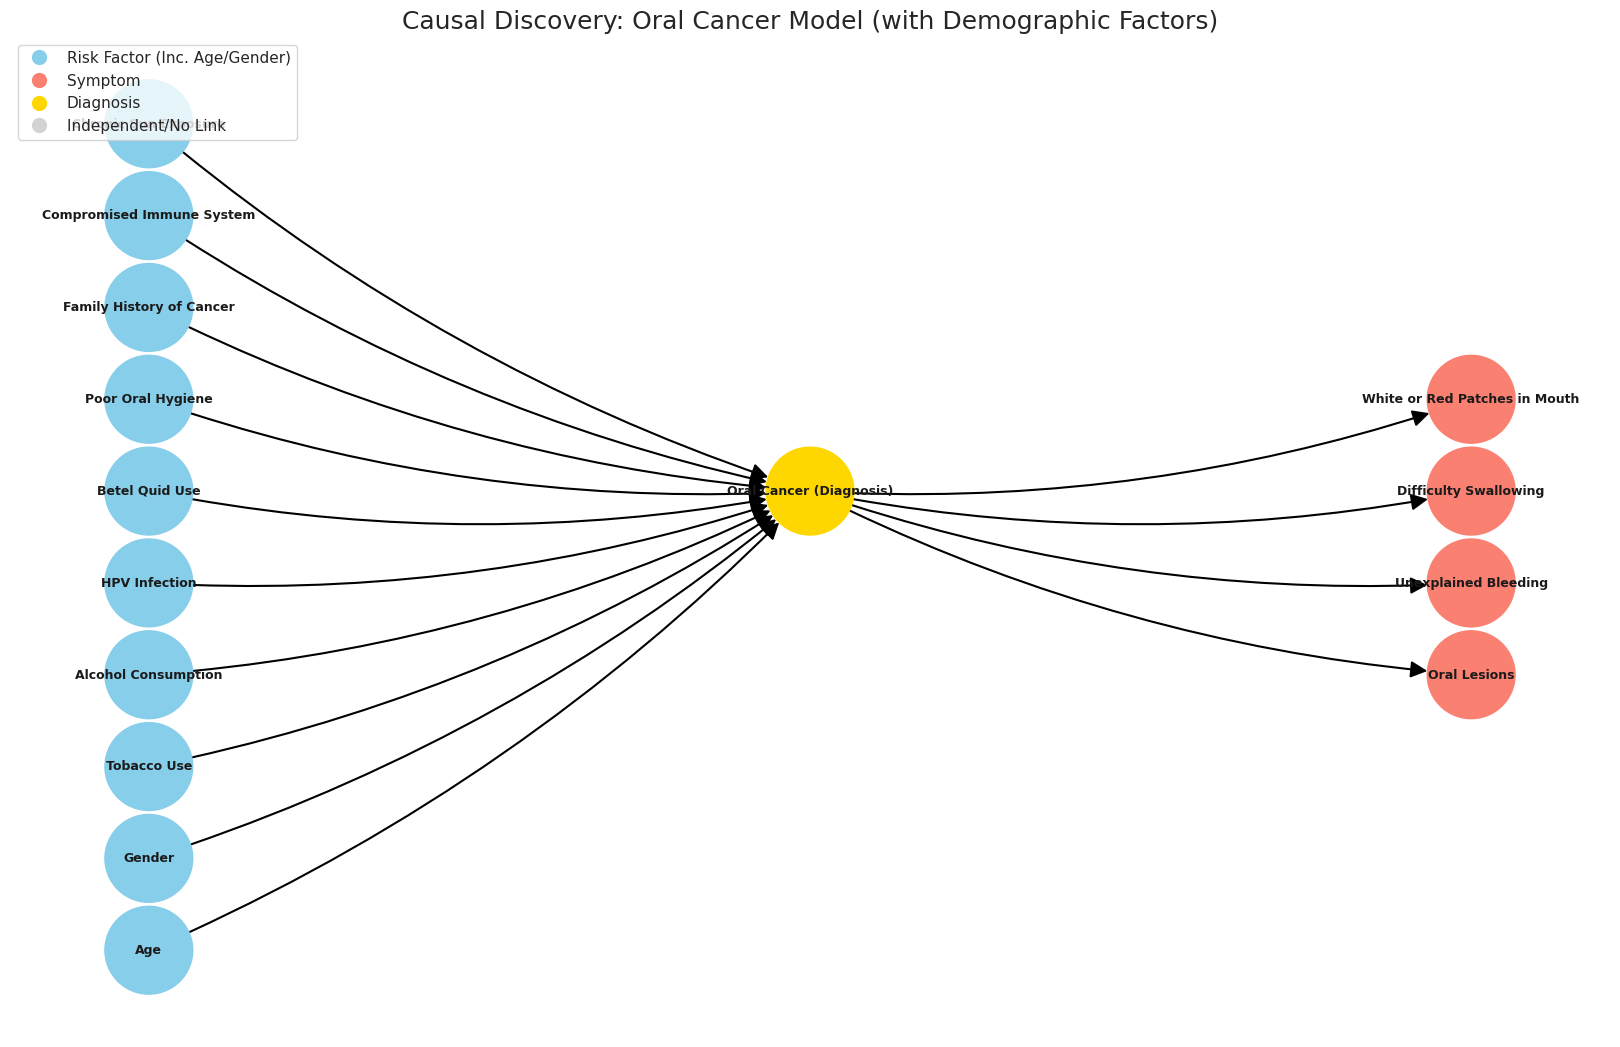

In [65]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from pgmpy.estimators import HillClimbSearch, K2
from pgmpy.models import BayesianNetwork

# --- 1. DATA PREPARATION & MAPPING ---
# Added Gender mapping here
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}

# Updated risk factors list to include Age and Gender
risk_factors = [
    'Age', 'Gender', 'Tobacco Use', 'Alcohol Consumption', 'HPV Infection',
    'Betel Quid Use', 'Poor Oral Hygiene', 'Family History of Cancer',
    'Compromised Immune System', 'Chronic Sun Exposure'
]
symptoms = [
    'Oral Lesions', 'Unexplained Bleeding', 'Difficulty Swallowing',
    'White or Red Patches in Mouth'
]
target = 'Oral Cancer (Diagnosis)'

df_model = df.copy()

# Cleaning loop: Maps strings to ints and ensures Age is numeric
for col in (risk_factors + symptoms + [target]):
    if col in df_model.columns:
        if df_model[col].dtype == 'object':
            df_model[col] = df_model[col].map(binary_map)

# Ensure we keep Age and Gender in the final dataframe
cols_to_keep = risk_factors + symptoms + [target]
df_model = df_model[cols_to_keep].dropna().astype(int)

# --- 2. CAUSAL DISCOVERY ---
hc = HillClimbSearch(df_model)
best_model = hc.estimate(scoring_method=K2(df_model))
edges = list(best_model.edges())

# Identify independent factors (nodes with no connections)
all_nodes = set(df_model.columns)
connected_nodes = set([u for u, v in edges] + [v for u, v in edges])
independent_factors = all_nodes - connected_nodes

# --- 3. VISUALIZATION (Hierarchical Layout) ---
plt.figure(figsize=(16, 10))

# Fallback: If no links are found, draw clinical logic paths
if not edges:
    print("No statistical links found. Drawing clinical logic model...")
    edges = [(rf, target) for rf in risk_factors] + [(target, sym) for sym in symptoms]
    independent_factors = []

G = nx.DiGraph(edges)

# Positioning: Risk factors (Left) -> Diagnosis (Center) -> Symptoms (Right)
pos = {}
for i, node in enumerate(risk_factors):
    # Distribute the risk factors (including Age/Gender) vertically on the left
    pos[node] = np.array([-1, i - len(risk_factors)/2])

pos[target] = np.array([0, 0])

for i, node in enumerate(symptoms):
    pos[node] = np.array([1, i - len(symptoms)/2])

# Handle any nodes caught in discovery that aren't in our predefined lists
for node in G.nodes():
    if node not in pos:
        pos[node] = np.array([0, -1])

# Node Colors
colors = []
for node in G.nodes():
    if node == target: colors.append('gold')
    elif node in symptoms: colors.append('salmon')
    elif node in independent_factors: colors.append('lightgrey')
    else: colors.append('skyblue') # Risk factors

# Draw the graph
nx.draw(G, pos, with_labels=True, node_size=4000, node_color=colors,
        font_size=9, font_weight='bold', arrows=True, arrowsize=25,
        edge_color='black', width=1.5, connectionstyle='arc3,rad=0.1')

# Custom Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Risk Factor (Inc. Age/Gender)', markerfacecolor='skyblue', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='Symptom', markerfacecolor='salmon', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='Diagnosis', markerfacecolor='gold', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='Independent/No Link', markerfacecolor='lightgrey', markersize=12)
]
plt.legend(handles=legend_elements, loc='upper left')

plt.title("Causal Discovery: Oral Cancer Model (with Demographic Factors)", fontsize=18)
plt.axis('off')
plt.show()

In [66]:
import pandas as pd
import numpy as np
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD

# 1. DEFINE FULL STRUCTURE
# Risk Factors -> Diagnosis -> Symptoms
structure = []
risk_factors = [
    'Age_bin', 'Gender', 'Tobacco Use', 'Alcohol Consumption', 'HPV Infection',
    'Betel Quid Use', 'Poor Oral Hygiene', 'Family History of Cancer',
    'Compromised Immune System', 'Chronic Sun Exposure'
]
symptoms = [
    'Oral Lesions', 'Unexplained Bleeding', 'Difficulty Swallowing',
    'White or Red Patches in Mouth'
]
target = 'Oral Cancer (Diagnosis)'

# Build edges: All Risks lead to Diagnosis; Diagnosis leads to all Symptoms
for rf in risk_factors:
    structure.append((rf, target))
for sym in symptoms:
    structure.append((target, sym))

model = DiscreteBayesianNetwork(structure)

# 2. DEFINE PRIOR CPDs (Root Nodes)
cpds = []

# Age (3 states)
cpds.append(TabularCPD('Age_bin', 3, [[0.3], [0.4], [0.3]],
                       state_names={'Age_bin': ['Young', 'Middle', 'Old']}))

# All other Binary Risk Factors (2 states)
binary_risks = [r for r in risk_factors if r != 'Age_bin']
for risk in binary_risks:
    cpds.append(TabularCPD(risk, 2, [[0.5], [0.5]],
                           state_names={risk: [0, 1]}))

# 3. GENERATE CONDITIONAL CPD FOR TARGET (Diagnosis)
# Evidence: 1 (Age: 3 states) + 9 (Binary: 2 states)
evidence_card = [3] + [2] * 9
total_combinations = np.prod(evidence_card) # 3 * 2^9 = 1536 combinations

values_target = np.random.dirichlet(np.ones(2), size=total_combinations).T

cpd_target = TabularCPD(
    variable=target,
    variable_card=2,
    values=values_target,
    evidence=risk_factors,
    evidence_card=evidence_card,
    state_names={target: [0, 1], **{rf: (['Young', 'Middle', 'Old'] if rf == 'Age_bin' else [0, 1]) for rf in risk_factors}}
)
cpds.append(cpd_target)

# 4. GENERATE CONDITIONAL CPDs FOR SYMPTOMS
# Symptoms depend ONLY on the Diagnosis (Target)
for sym in symptoms:
    # Randomly generate a 2x2 table (Target=0 or 1 -> Symptom=0 or 1)
    values_sym = np.random.dirichlet(np.ones(2), size=2).T
    cpds.append(TabularCPD(
        variable=sym,
        variable_card=2,
        values=values_sym,
        evidence=[target],
        evidence_card=[2],
        state_names={sym: [0, 1], target: [0, 1]}
    ))

# 5. ASSEMBLE AND VALIDATE
model.add_cpds(*cpds)

if model.check_model():
    print(f"Success: Model valid with {len(risk_factors)} risks and {len(symptoms)} symptoms.")
    print(f"Target node '{target}' accounts for {total_combinations} parent combinations.")

Success: Model valid with 10 risks and 4 symptoms.
Target node 'Oral Cancer (Diagnosis)' accounts for 1536 parent combinations.


In [67]:
print(model.get_cpds('Oral Cancer (Diagnosis)'))

+----------------------------+-----+------------------------------+
| Age_bin                    | ... | Age_bin(Old)                 |
+----------------------------+-----+------------------------------+
| Gender                     | ... | Gender(1)                    |
+----------------------------+-----+------------------------------+
| Tobacco Use                | ... | Tobacco Use(1)               |
+----------------------------+-----+------------------------------+
| Alcohol Consumption        | ... | Alcohol Consumption(1)       |
+----------------------------+-----+------------------------------+
| HPV Infection              | ... | HPV Infection(1)             |
+----------------------------+-----+------------------------------+
| Betel Quid Use             | ... | Betel Quid Use(1)            |
+----------------------------+-----+------------------------------+
| Poor Oral Hygiene          | ... | Poor Oral Hygiene(1)         |
+----------------------------+-----+------------

In [68]:
print("\nBayesian Network CPDs:")
for cpd in model.get_cpds():
    print(cpd)


Bayesian Network CPDs:
+-----------------+-----+
| Age_bin(Young)  | 0.3 |
+-----------------+-----+
| Age_bin(Middle) | 0.4 |
+-----------------+-----+
| Age_bin(Old)    | 0.3 |
+-----------------+-----+
+-----------+-----+
| Gender(0) | 0.5 |
+-----------+-----+
| Gender(1) | 0.5 |
+-----------+-----+
+----------------+-----+
| Tobacco Use(0) | 0.5 |
+----------------+-----+
| Tobacco Use(1) | 0.5 |
+----------------+-----+
+------------------------+-----+
| Alcohol Consumption(0) | 0.5 |
+------------------------+-----+
| Alcohol Consumption(1) | 0.5 |
+------------------------+-----+
+------------------+-----+
| HPV Infection(0) | 0.5 |
+------------------+-----+
| HPV Infection(1) | 0.5 |
+------------------+-----+
+-------------------+-----+
| Betel Quid Use(0) | 0.5 |
+-------------------+-----+
| Betel Quid Use(1) | 0.5 |
+-------------------+-----+
+----------------------+-----+
| Poor Oral Hygiene(0) | 0.5 |
+----------------------+-----+
| Poor Oral Hygiene(1) | 0.5 |
+----

In [69]:
# Display unique treatment categories
print(df['Treatment Type'].unique())

['No Treatment' 'Surgery' 'Radiation' 'Targeted Therapy' 'Chemotherapy']


In [70]:
# Display unique early diagnosis categories
print(df['Early Diagnosis'].unique())

['No' 'Yes']


In [71]:
# Display unique cancer stage categories
print(df['Cancer Stage'].unique())

[0 1 2 3 4]


In [72]:
# Display unique Survival Rate categories
print(df['Survival Rate (5-Year, %)'].unique())

[100.          83.34010314  63.22287106 ...  17.45600815  85.22156524
  85.63342617]


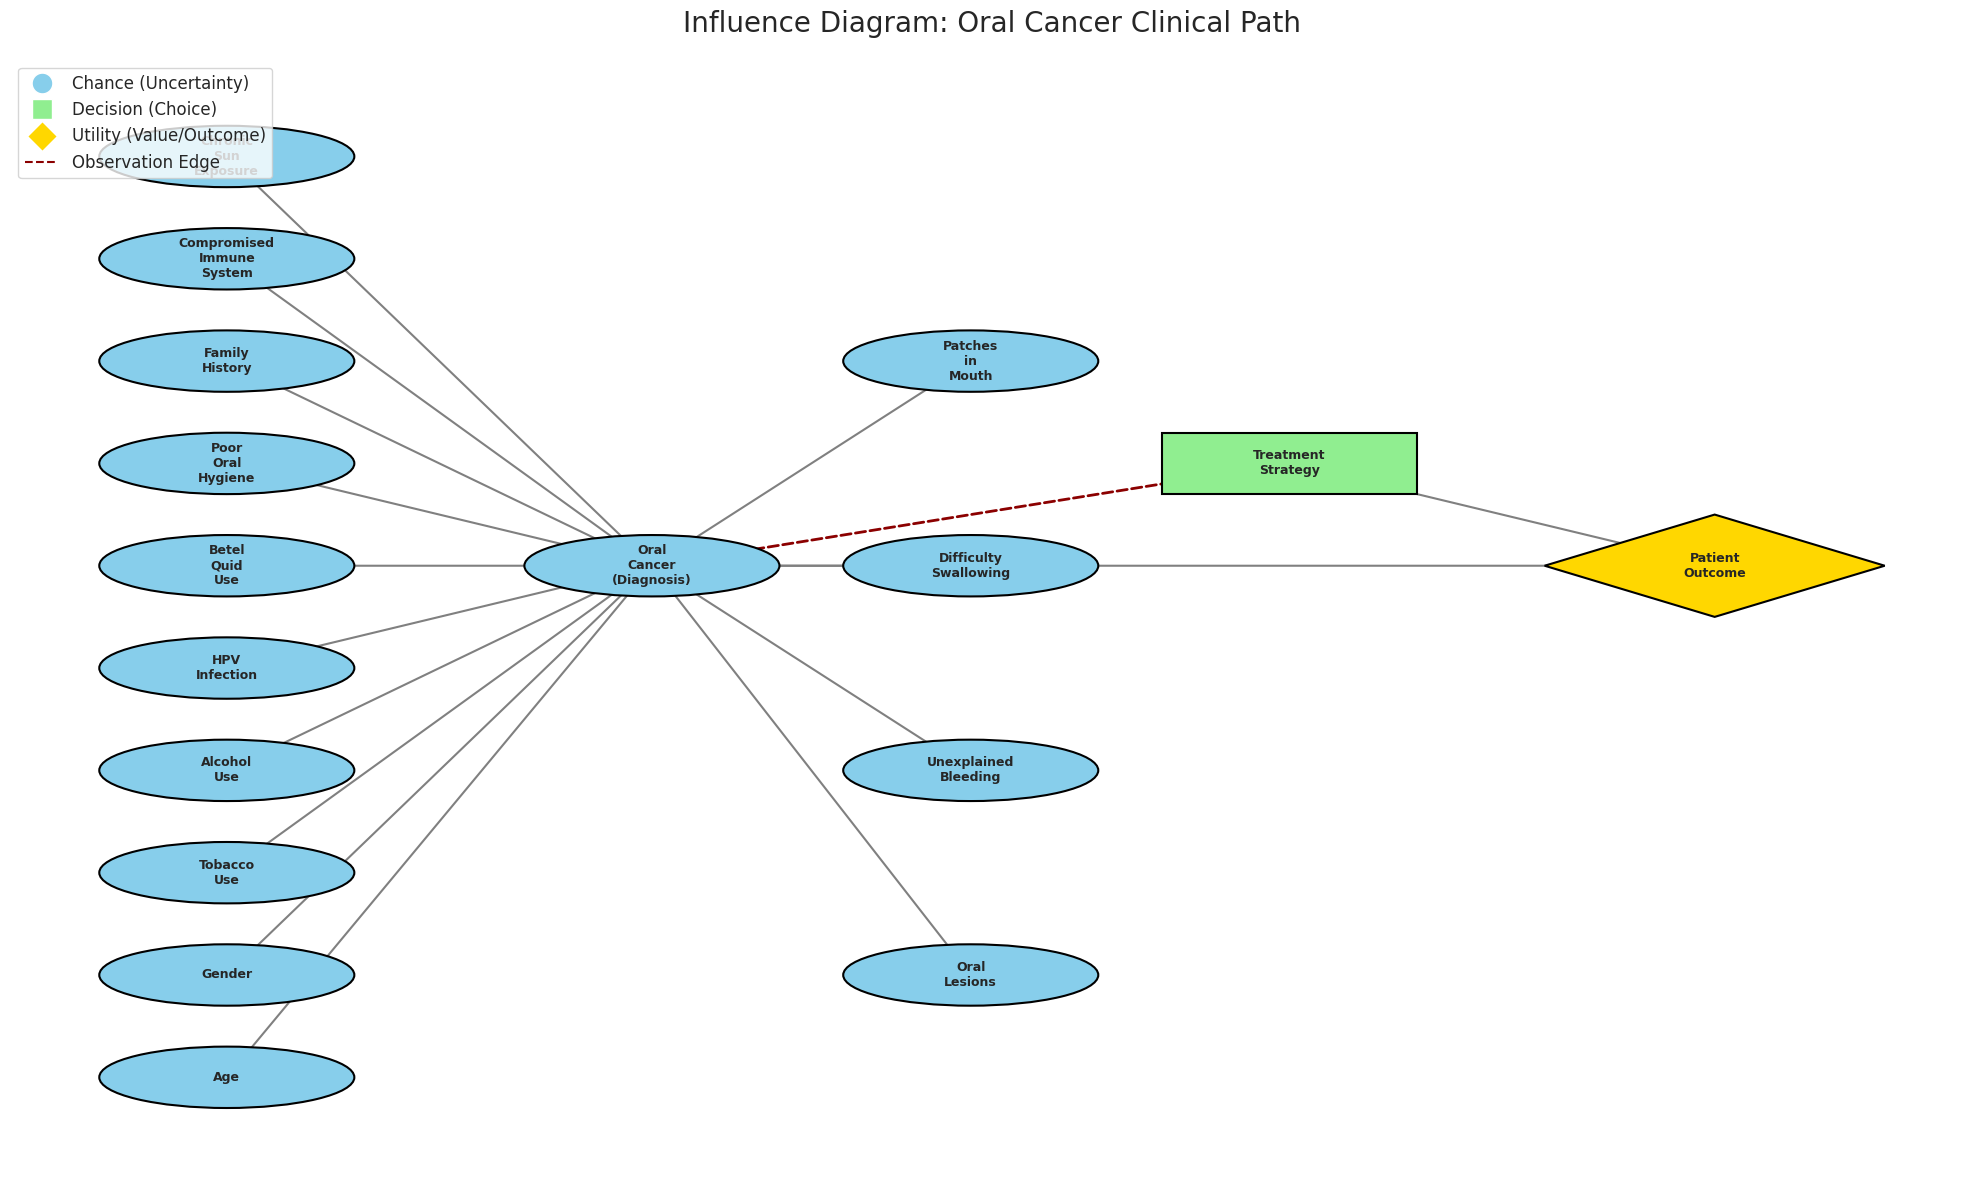

In [73]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle, Ellipse
import numpy as np

# 1. INITIALIZE GRAPH
G = nx.DiGraph()

# 2. DEFINE NODES BY TYPE
risk_factors = [
    'Age', 'Gender', 'Tobacco Use', 'Alcohol Use', 'HPV Infection',
    'Betel Quid Use', 'Poor Oral Hygiene', 'Family History',
    'Compromised Immune System', 'Chronic Sun Exposure'
]
symptoms = [
    'Oral Lesions', 'Unexplained Bleeding',
    'Difficulty Swallowing', 'Patches in Mouth'
]
target = 'Oral Cancer (Diagnosis)'
decision = 'Treatment Strategy'
utility = 'Patient Outcome'

# Add Chance Nodes (Ovals)
for node in risk_factors + symptoms + [target]:
    G.add_node(node, type='chance')

# Add Decision Node (Rectangle)
G.add_node(decision, type='decision')

# Add Utility Node (Diamond)
G.add_node(utility, type='utility')

# 3. DEFINE EDGES
# Risks -> Diagnosis
G.add_edges_from([(rf, target) for rf in risk_factors])

# Diagnosis -> Symptoms
G.add_edges_from([(target, sym) for sym in symptoms])

# Diagnosis informs Decision (Observation)
G.add_edge(target, decision)

# Decision and Diagnosis -> Outcome
G.add_edge(target, utility)
G.add_edge(decision, utility)

# 4. MANUAL LAYOUT (Left to Right Flow)
pos = {}
# Risk factors column
for i, node in enumerate(risk_factors):
    pos[node] = np.array([-2, i - len(risk_factors)/2])

# Diagnosis (Center)
pos[target] = np.array([0, 0])

# Symptoms (Top/Bottom Right of Center)
for i, node in enumerate(symptoms):
    pos[node] = np.array([1.5, (i - len(symptoms)/2) * 2])

# Decision and Utility
pos[decision] = np.array([3, 1])
pos[utility] = np.array([5, 0])

# 5. DRAWING
plt.figure(figsize=(20, 12))
ax = plt.gca()

for node, data in G.nodes(data=True):
    x, y = pos[node]
    ntype = data['type']

    if ntype == 'chance':
        shape = Ellipse((x, y), width=1.2, height=0.6, facecolor='skyblue', edgecolor='black', lw=1.5, zorder=2)
    elif ntype == 'decision':
        shape = Rectangle((x-0.6, y-0.3), 1.2, 0.6, facecolor='lightgreen', edgecolor='black', lw=1.5, zorder=2)
    elif ntype == 'utility':
        verts = [(x, y+0.5), (x+0.8, y), (x, y-0.5), (x-0.8, y)]
        shape = Polygon(verts, facecolor='gold', edgecolor='black', lw=1.5, zorder=2)

    ax.add_patch(shape)
    plt.text(x, y, node.replace(' ', '\n'), fontsize=9, ha='center', va='center', weight='bold', zorder=3)

# Separate edge types for styling
observation_edges = [(target, decision)]
influence_edges = [e for e in G.edges() if e not in observation_edges]

# Draw Influence edges (Solid)
nx.draw_networkx_edges(G, pos, edgelist=influence_edges, arrowstyle='-|>',
                       arrowsize=20, edge_color='gray', width=1.5, node_size=0)

# Draw Observation edges (Dashed)
nx.draw_networkx_edges(G, pos, edgelist=observation_edges, arrowstyle='-|>',
                       arrowsize=20, edge_color='darkred', width=2, style='dashed', node_size=0)

# 6. LEGEND AND FINISH
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Chance (Uncertainty)', markerfacecolor='skyblue', markersize=15),
    Line2D([0], [0], marker='s', color='w', label='Decision (Choice)', markerfacecolor='lightgreen', markersize=15),
    Line2D([0], [0], marker='D', color='w', label='Utility (Value/Outcome)', markerfacecolor='gold', markersize=15),
    Line2D([0], [0], color='darkred', linestyle='--', label='Observation Edge')
]
plt.legend(handles=legend_elements, loc='upper left', fontsize=12)
plt.title("Influence Diagram: Oral Cancer Clinical Path", fontsize=20, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

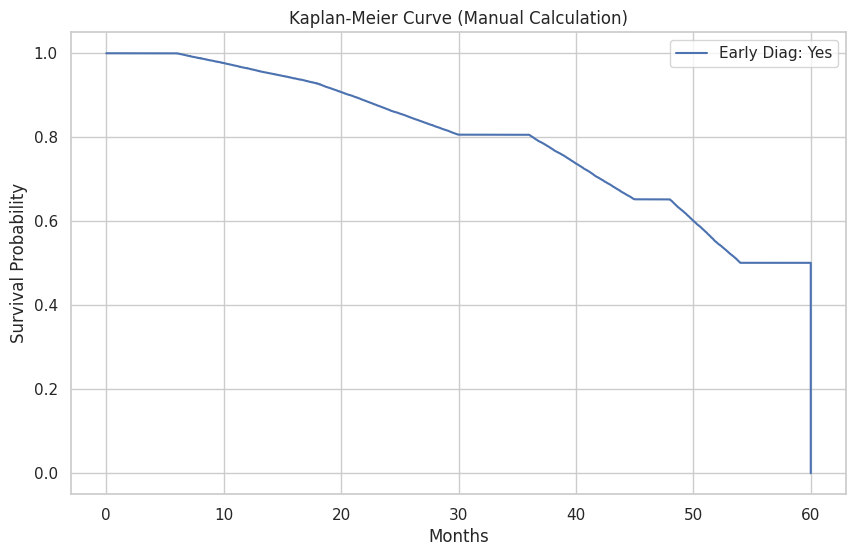

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Filter for diagnosed patients and set a time horizon
cancer_df = df[df['Early Diagnosis'] == 'Yes'].copy()
cancer_df['Time_Months'] = cancer_df['Survival Rate (5-Year, %)'] * 0.6

def plot_km(data, column, label_prefix):
    for status in data[column].unique():
        sub = data[data[column] == status].sort_values('Time_Months')
        times = [0] + list(sub['Time_Months'].unique())
        probs = [1.0]
        n_at_risk = len(sub)
        curr_prob = 1.0

        for t in times[1:]:
            d_t = len(sub[sub['Time_Months'] == t])
            curr_prob *= (1 - d_t / n_at_risk)
            probs.append(curr_prob)
            n_at_risk -= d_t

        plt.step(times, probs, where='post', label=f'{label_prefix}: {status}')

# 2. Generate the plot
plt.figure(figsize=(10, 6))
plot_km(cancer_df, 'Early Diagnosis', 'Early Diag')
plt.title('Kaplan-Meier Curve (Manual Calculation)')
plt.ylabel('Survival Probability')
plt.xlabel('Months')
plt.legend()
plt.show()

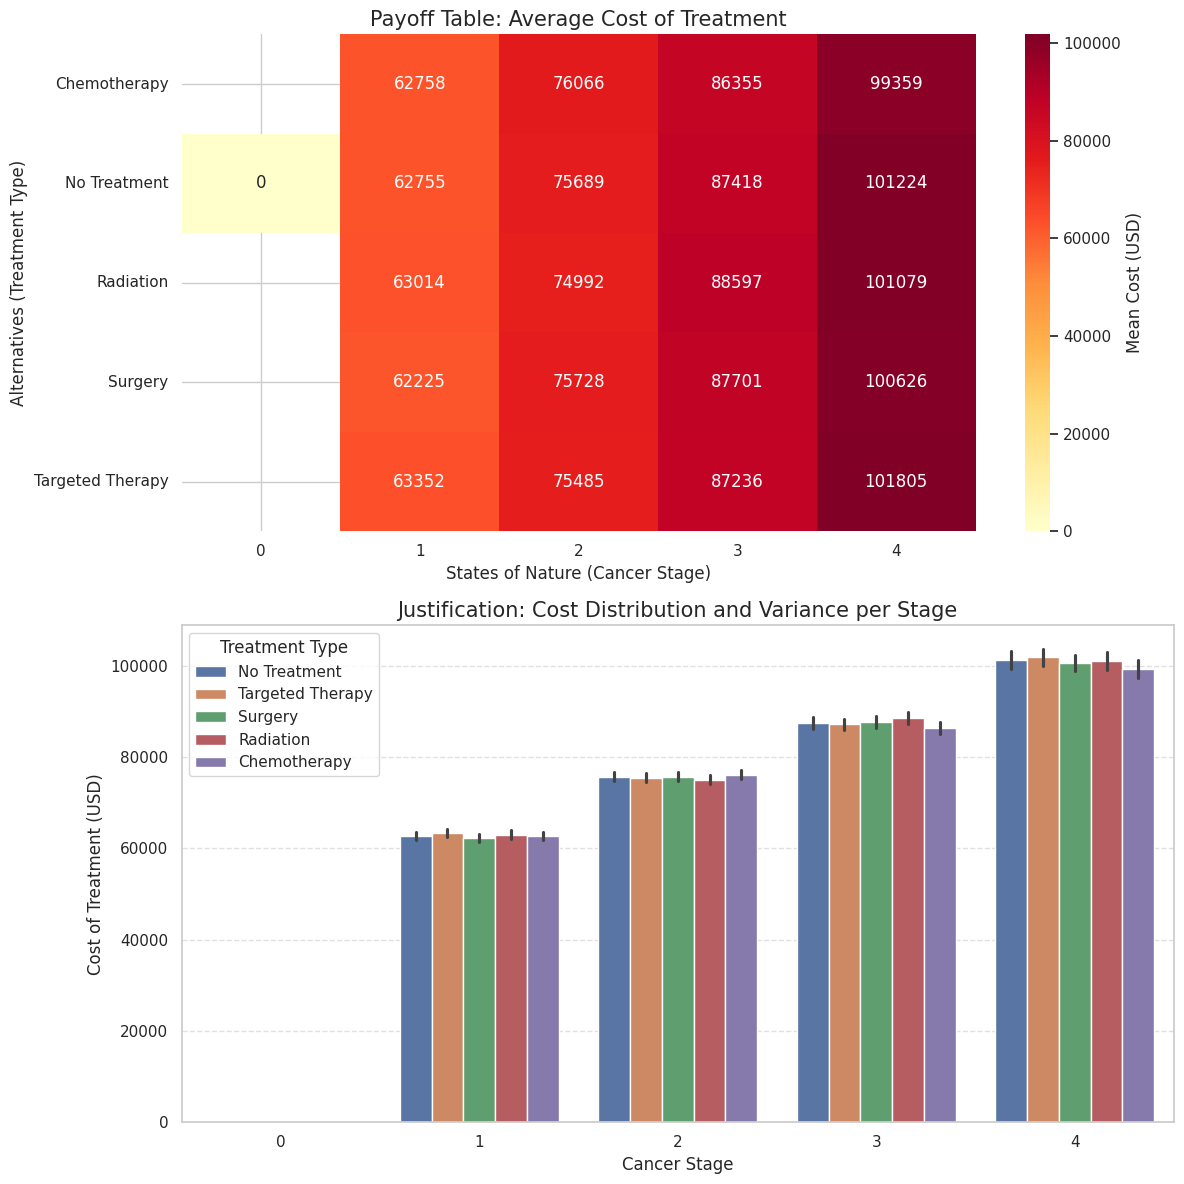


--- Summary Payoff Table (Average Costs) ---


Cancer Stage,0,1,2,3,4
Treatment Type,,,,,
Chemotherapy,NaN,62758.084772,76065.592044,86354.579118,99359.198098
No Treatment,0.0,62754.977087,75688.832278,87418.493750,101224.206336
Radiation,NaN,63014.113015,74992.193261,88597.205041,101078.790024
Surgery,NaN,62225.022007,75727.653181,87701.262261,100625.704057
Targeted Therapy,NaN,63351.675426,75485.092060,87235.506492,101804.751987


In [75]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



# 2. Generate the Payoff Matrix (using Mean Cost)
# Rows = Treatment Type (Alternatives), Columns = Cancer Stage (States of Nature)
payoff_matrix = df.pivot_table(
    values='Cost of Treatment (USD)',
    index='Treatment Type',
    columns='Cancer Stage',
    aggfunc='mean'
)

# 3. Create the Visual EDA
plt.figure(figsize=(12, 12))

# Plot A: Heatmap of the Payoff Table
# This provides a visual representation of your decision matrix
plt.subplot(2, 1, 1)
sns.heatmap(payoff_matrix, annot=True, fmt=".0f", cmap="YlOrRd", cbar_kws={'label': 'Mean Cost (USD)'})
plt.title('Payoff Table: Average Cost of Treatment', fontsize=15)
plt.ylabel('Alternatives (Treatment Type)')
plt.xlabel('States of Nature (Cancer Stage)')

# Plot B: Bar Chart for Justification
# Error bars show the variation (Standard Deviation) in costs per category
plt.subplot(2, 1, 2)
sns.barplot(x='Cancer Stage', y='Cost of Treatment (USD)', hue='Treatment Type', data=df)
plt.title('Justification: Cost Distribution and Variance per Stage', fontsize=15)
plt.ylabel('Cost of Treatment (USD)')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 4. Display the raw Payoff Table for verification
print("\n--- Summary Payoff Table (Average Costs) ---")
display(payoff_matrix)